In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def backtest(return_data, quarter_weights):
    return quarter_weights.groupby(by='quarter').apply(lambda x: compute_weighted_return(return_data, x))

def compute_weighted_return(return_data, group):
    quarter = group.name
    data = return_data.loc[return_data['quarter'] == quarter, :].copy()
    data.drop('quarter', axis=1, inplace=True)
    group = group.set_index('stock')
    return (group['weight'] * data).sum(axis=1)



In [50]:
import pandas as pd
re_data = pd.read_csv('all_stock_returns.csv')
re_data['交易日期'] = pd.to_datetime(re_data['交易日期'], format='%Y-%m-%d')
re_data = re_data[re_data['交易日期' ]>= '2017-01-01'].reset_index()
re_data.set_index('交易日期', inplace=True)
re_data.fillna(0, inplace=True)
re_data.drop('index', axis=1, inplace=True)
# re_data['沪深300'] = re_data['沪深300'].str.rstrip('%').astype(float)
q_data = re_data.resample('Q').apply(lambda x: ((1 + x/100).prod() - 1)*100)
q_data.index = q_data.index.to_period('Q')
q_data.rename_axis('quarter', axis=0, inplace=True)
q_data.reset_index(inplace=True)
q_data.to_csv('quarter_return.csv', index=False)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_346284\2481177295.py:9: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_data = re_data.resample('Q').apply(lambda x: ((1 + x/100).prod() - 1)*100)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_346284\2481177295.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  q_data.reset_index(inplace=True)


In [95]:
re_data

,688981,688599,688506,688472,688396,688303,688271,688256,688223,688187,...,000338,000333,000301,000166,000157,000100,000063,000002,000001,沪深300
交易日期,,,,,,,,,,,,,,,,,,,,,
2017-01-03,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.1000,3.3700,0.9300,0.0000,0.0000,3.9400,1.5700,0.8800,0.6600,0.97
2017-01-04,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,3.3100,2.4400,0.5600,0.0000,0.8800,-0.2900,-0.3100,0.5800,0.0000,0.78
2017-01-05,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.2900,-0.4700,-1.2900,0.0000,1.5300,0.0000,-1.6700,0.3800,0.1100,-0.02
2017-01-06,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,-0.3900,-1.0100,0.0000,0.0000,-0.6500,-0.8800,-1.5700,-1.3900,-0.4400,-0.60
2017-01-09,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,1.1700,-0.4800,2.6100,0.0000,0.8700,0.8900,-3.7100,0.1000,0.2200,0.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-01,0.7042,-2.2664,-1.3992,-6.9186,9.6920,1.3603,-1.3524,2.3621,1.4210,-2.7505,...,0.3466,0.1753,0.1041,0.5825,0.0000,2.6895,10.0024,-3.3457,0.6891,1.10
2025-12-02,-1.2238,-1.3575,-1.2668,0.5621,-3.0434,-3.8541,-1.9726,-2.4742,-1.9264,0.1032,...,-1.4968,1.9500,1.0395,-1.1583,1.2376,-0.7143,-1.7279,0.0000,-0.4277,-0.48
2025-12-03,-1.2212,-2.5229,-2.0951,-2.2981,7.9384,-0.6442,0.1321,0.2687,-2.8571,0.3712,...,-0.1753,0.7479,-0.9259,-1.1719,0.8557,4.0767,-4.8352,-3.6538,-0.7732,-0.51


In [96]:
def visualize_all(avg_return):
    avg_return['quarter'] = avg_return['quarter'].astype(str)

    # Plot 1: Quarterly Returns
    fig1, ax1 = plt.subplots(figsize=(12, 6))
    fig1.patch.set_facecolor('black')   # Set entire canvas background to black
    ax1.set_facecolor('black')          # Set plot area background to black

    ax1.plot(avg_return['quarter'], avg_return['nlp_return'], label='NLP Strategy',
             color='#FF6B6B', linewidth=2.5, marker='o')
    ax1.plot(avg_return['quarter'], avg_return['HS300Index'], label='HS300Index',
             color='#4ECDC4', linewidth=2.5, marker='s')
    ax1.axhline(y=0, color='white', linestyle='--', alpha=0.7)
    ax1.set_title('Quarterly Return', color='white')
    ax1.set_ylabel('Return (%)', color='white')
    # Format legend after plotting curves
    legend = ax1.legend(facecolor='black', edgecolor='white')   # Legend background black, border white
    for text in legend.get_texts():
        text.set_color("white")   # Set legend text to white

    ax1.grid(True, alpha=0.3, color='white')
    plt.xticks(rotation=45, ha='right', color='white')
    plt.yticks(color='white')
    plt.tight_layout()
    plt.show()

    # Plot 2: Cumulative Returns
    fig2, ax2 = plt.subplots(figsize=(12, 6))
    fig2.patch.set_facecolor('black')
    ax2.set_facecolor('black')

    ax2.plot(avg_return['quarter'], avg_return['nlp_cum_return'], label='NLP Strategy (Cumulative)',
             color='#FF6B6B', linewidth=2.5, marker='o')
    ax2.plot(avg_return['quarter'], avg_return['HS300_cum_return'], label='HS300Index (Cumulative)',
             color='#4ECDC4', linewidth=2.5, marker='s')
    ax2.set_title('Cumulative Compounded Return', color='white')
    ax2.set_ylabel('Cumulative Return', color='white')
    # Format legend after plotting curves
    legend = ax2.legend(facecolor='black', edgecolor='white')   # Legend background black, border white
    for text in legend.get_texts():
        text.set_color("white")   # Set legend text to white
    ax2.grid(True, alpha=0.3, color='white')
    plt.xticks(rotation=45, ha='right', color='white')
    plt.yticks(color='white')
    plt.tight_layout()
    plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_95348\1666145431.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return quarter_weights.groupby(by='quarter').apply(lambda x: compute_weighted_return(return_data, x))


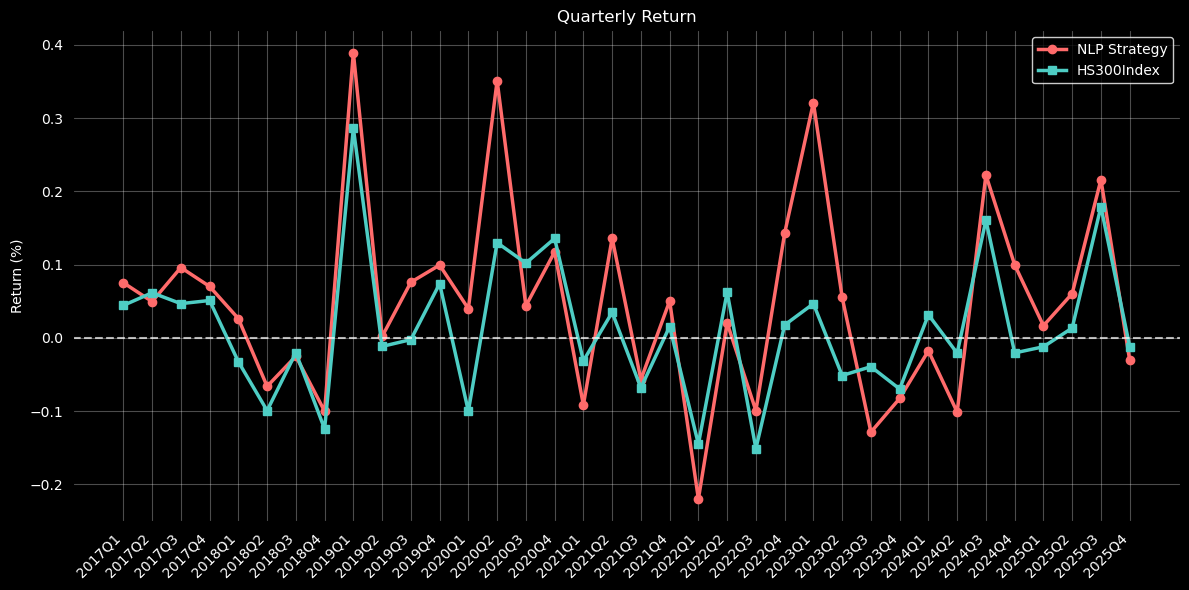

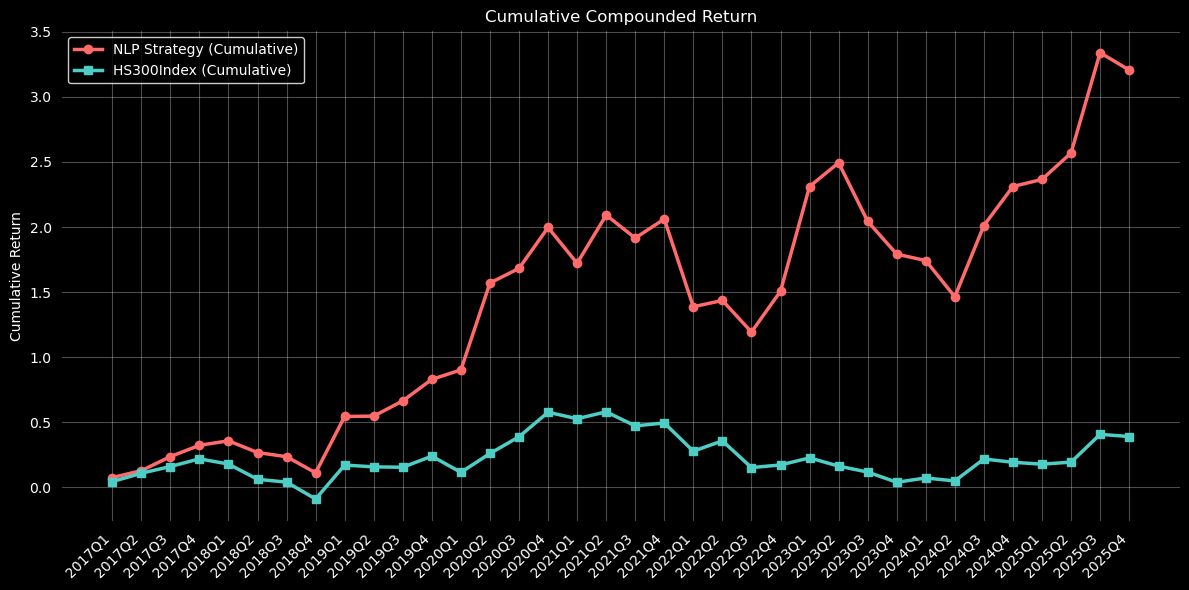

📊 Total Cumulative Returns
NLP Strategy - Total Return: 320.63%
CSI300 Index - Total Return: 39.05%
📈 Portfolio Performance Metrics
NLP Strategy - Sharpe Ratio: 0.3648
NLP Strategy - Information Ratio: 0.4456
CSI300 Index - Sharpe Ratio: 0.1426
CSI300 Index - Information Ratio: 0.0000


In [97]:
q_data = pd.read_csv('quarter_return.csv')
q_data['quarter'] = pd.PeriodIndex(q_data['quarter'], freq='Q')
hs_data = q_data[['quarter', '沪深300']].copy()
hs_data.rename(columns={'沪深300': 'HS300Index'}, inplace=True)
q_data.drop('沪深300', axis=1, inplace=True)

weights = pd.read_csv('quarterly_weights_sentiment.csv')
weights['quarter'] = pd.PeriodIndex(weights['quarter'].str.replace('_', ''), freq='Q')
weights['stock'] = weights['stock'].astype(str).str.zfill(6)

avg_return = backtest(q_data, weights)
avg_return = avg_return.droplevel(1)
avg_return.name = 'nlp_return'
avg_return = avg_return.reset_index()

avg_return = avg_return.merge(hs_data, on='quarter', how='outer')

# Convert percentage to decimal (if original data is in percentage)
avg_return['nlp_return'] = avg_return['nlp_return'] / 100
avg_return['HS300Index'] = avg_return['HS300Index'] / 100

# Calculate cumulative compounded returns
avg_return['nlp_cum_return'] = (1 + avg_return['nlp_return']).cumprod() - 1
avg_return['HS300_cum_return'] = (1 + avg_return['HS300Index']).cumprod() - 1

# Calculate monthly returns (assuming quarterly returns are compounded)
avg_return['nlp_monthly_return'] = (1 + avg_return['nlp_return'])**(1/3) - 1
avg_return['HS300_monthly_return'] = (1 + avg_return['HS300Index'])**(1/3) - 1

# Optional: Save results
# avg_return.to_csv('avg_return.csv', index=True)

# Display visualizations
visualize_all(avg_return)


# === Sharpe Ratio Calculation ===
# NLP Strategy
mean_nlp = avg_return['nlp_return'].mean()
std_nlp = avg_return['nlp_return'].std()
sharpe_nlp = mean_nlp / std_nlp if std_nlp != 0 else np.nan

# CSI300 Index
mean_csi = avg_return['HS300Index'].mean()
std_csi = avg_return['HS300Index'].std()
sharpe_csi = mean_csi / std_csi if std_csi != 0 else np.nan

# === Information Ratio Calculation ===
# NLP Strategy vs CSI300 benchmark
excess_nlp = avg_return['nlp_return'] - avg_return['HS300Index']
mean_excess_nlp = excess_nlp.mean()
std_excess_nlp = excess_nlp.std()
info_ratio_nlp = mean_excess_nlp / std_excess_nlp if std_excess_nlp != 0 else np.nan

# CSI300 benchmark information ratio = 0
info_ratio_csi = 0.0

final_nlp_return = avg_return['nlp_cum_return'].iloc[-1] 
final_csi_return = avg_return['HS300_cum_return'].iloc[-1] 
print("📊 Total Cumulative Returns") 
print(f"NLP Strategy - Total Return: {final_nlp_return:.2%}") 
print(f"CSI300 Index - Total Return: {final_csi_return:.2%}")
print("📈 Portfolio Performance Metrics")
print(f"NLP Strategy - Sharpe Ratio: {sharpe_nlp:.4f}")
print(f"NLP Strategy - Information Ratio: {info_ratio_nlp:.4f}")
print(f"CSI300 Index - Sharpe Ratio: {sharpe_csi:.4f}")
print(f"CSI300 Index - Information Ratio: {info_ratio_csi:.4f}")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_95348\1666145431.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return quarter_weights.groupby(by='quarter').apply(lambda x: compute_weighted_return(return_data, x))


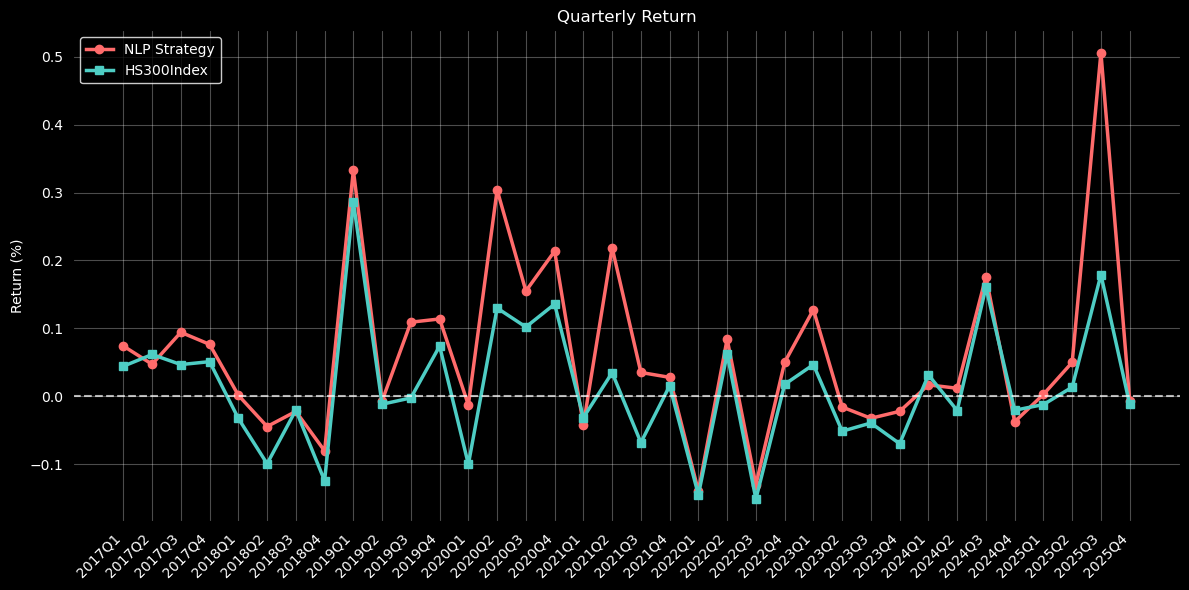

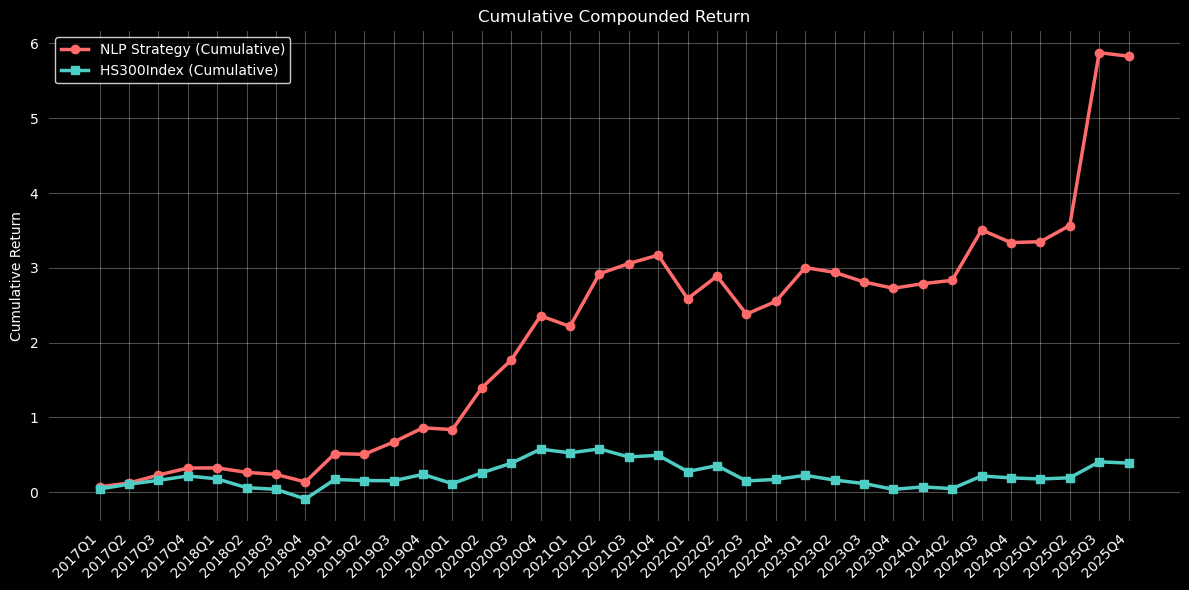

📊 Total Cumulative Returns
NLP Strategy - Total Return: 582.87%
CSI300 Index - Total Return: 39.05%
📈 Portfolio Performance Metrics
NLP Strategy - Sharpe Ratio: 0.4743
NLP Strategy - Information Ratio: 0.7332
CSI300 Index - Sharpe Ratio: 0.1426
CSI300 Index - Information Ratio: 0.0000


In [98]:
q_data = pd.read_csv('quarter_return.csv')
q_data['quarter'] = pd.PeriodIndex(q_data['quarter'], freq='Q')
hs_data = q_data[['quarter', '沪深300']].copy()
hs_data.rename(columns={'沪深300': 'HS300Index'}, inplace=True)
q_data.drop('沪深300', axis=1, inplace=True)

weights = pd.read_csv('quarterly_weights_inference.csv')
weights['quarter'] = pd.PeriodIndex(weights['quarter'].str.replace('_', ''), freq='Q')
weights['stock'] = weights['stock'].astype(str).str.zfill(6)

avg_return = backtest(q_data, weights)
avg_return = avg_return.droplevel(1)
avg_return.name = 'nlp_return'
avg_return = avg_return.reset_index()

avg_return = avg_return.merge(hs_data, on='quarter', how='outer')

# Convert percentage to decimal (if original data is in percentage)
avg_return['nlp_return'] = avg_return['nlp_return'] / 100
avg_return['HS300Index'] = avg_return['HS300Index'] / 100

# Calculate cumulative compounded returns
avg_return['nlp_cum_return'] = (1 + avg_return['nlp_return']).cumprod() - 1
avg_return['HS300_cum_return'] = (1 + avg_return['HS300Index']).cumprod() - 1

# Calculate monthly returns (assuming quarterly returns are compounded)
avg_return['nlp_monthly_return'] = (1 + avg_return['nlp_return'])**(1/3) - 1
avg_return['HS300_monthly_return'] = (1 + avg_return['HS300Index'])**(1/3) - 1

# Optional: Save results
# avg_return.to_csv('avg_return.csv', index=True)

# Display visualizations
visualize_all(avg_return)


# === Sharpe Ratio Calculation ===
# NLP Strategy
mean_nlp = avg_return['nlp_return'].mean()
std_nlp = avg_return['nlp_return'].std()
sharpe_nlp = mean_nlp / std_nlp if std_nlp != 0 else np.nan

# CSI300 Index
mean_csi = avg_return['HS300Index'].mean()
std_csi = avg_return['HS300Index'].std()
sharpe_csi = mean_csi / std_csi if std_csi != 0 else np.nan

# === Information Ratio Calculation ===
# NLP Strategy vs CSI300 benchmark
excess_nlp = avg_return['nlp_return'] - avg_return['HS300Index']
mean_excess_nlp = excess_nlp.mean()
std_excess_nlp = excess_nlp.std()
info_ratio_nlp = mean_excess_nlp / std_excess_nlp if std_excess_nlp != 0 else np.nan

# CSI300 benchmark information ratio = 0
info_ratio_csi = 0.0

final_nlp_return = avg_return['nlp_cum_return'].iloc[-1] 
final_csi_return = avg_return['HS300_cum_return'].iloc[-1] 
print("📊 Total Cumulative Returns") 
print(f"NLP Strategy - Total Return: {final_nlp_return:.2%}") 
print(f"CSI300 Index - Total Return: {final_csi_return:.2%}")
print("📈 Portfolio Performance Metrics")
print(f"NLP Strategy - Sharpe Ratio: {sharpe_nlp:.4f}")
print(f"NLP Strategy - Information Ratio: {info_ratio_nlp:.4f}")
print(f"CSI300 Index - Sharpe Ratio: {sharpe_csi:.4f}")
print(f"CSI300 Index - Information Ratio: {info_ratio_csi:.4f}")

In [99]:
import pandas as pd

# Read the weights file
df = pd.read_csv("weight_change_inference.csv")

# Standardize stock codes as strings to avoid type inconsistencies
df['stock'] = df['stock'].astype(str).str.zfill(6)

# Check for duplicate (quarter, stock) pairs
dup_rows = df[df.duplicated(subset=['quarter','stock'], keep=False)]
print("Number of duplicate (quarter, stock) rows:", len(dup_rows))
if len(dup_rows) > 0:
    print("Example duplicate rows:")
    print(dup_rows.head(10))

# Check if stocks appear across multiple quarters (normal, but we can count them)
stock_counts = df.groupby('stock')['quarter'].nunique()
multi_quarters = stock_counts[stock_counts > 1]
print("Number of stocks appearing in multiple quarters:", len(multi_quarters))

# Check if quarter format is consistent
print("Sample quarter unique values:", df['quarter'].unique()[:10])

Number of duplicate (quarter, stock) rows: 0
Number of stocks appearing in multiple quarters: 300
Sample quarter unique values: ['2017_Q1' '2017_Q2' '2017_Q3' '2017_Q4' '2018_Q1' '2018_Q2' '2018_Q3'
 '2018_Q4' '2019_Q1' '2019_Q2']


# Daily Backtest


📊 Total Cumulative Returns
Equal-Weight Benchmark - Total Return: 342.65%
CSI300 Benchmark - Total Return: 37.72%
NLP Strategy - Total Return: 109.48%
Overlay Strategy - Total Return: 748.85%
📈 Portfolio Performance Metrics (Annualized)
Equal-Weight Benchmark - Sharpe: 1.0867
CSI300 Benchmark - Sharpe: 0.2929
NLP Strategy - Sharpe: 0.5054
Overlay Strategy - Sharpe: 0.9523
Overlay Strategy - Information Ratio vs Equal-Weight Benchmark: 0.5054
NLP Strategy - Information Ratio vs Equal-Weight Benchmark: -0.3322


C:\Users\Administrator\AppData\Local\Temp\ipykernel_95348\3662938460.py:152: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return daily_weights.groupby(by='date').apply(lambda x: compute_weighted_return(return_data, x))


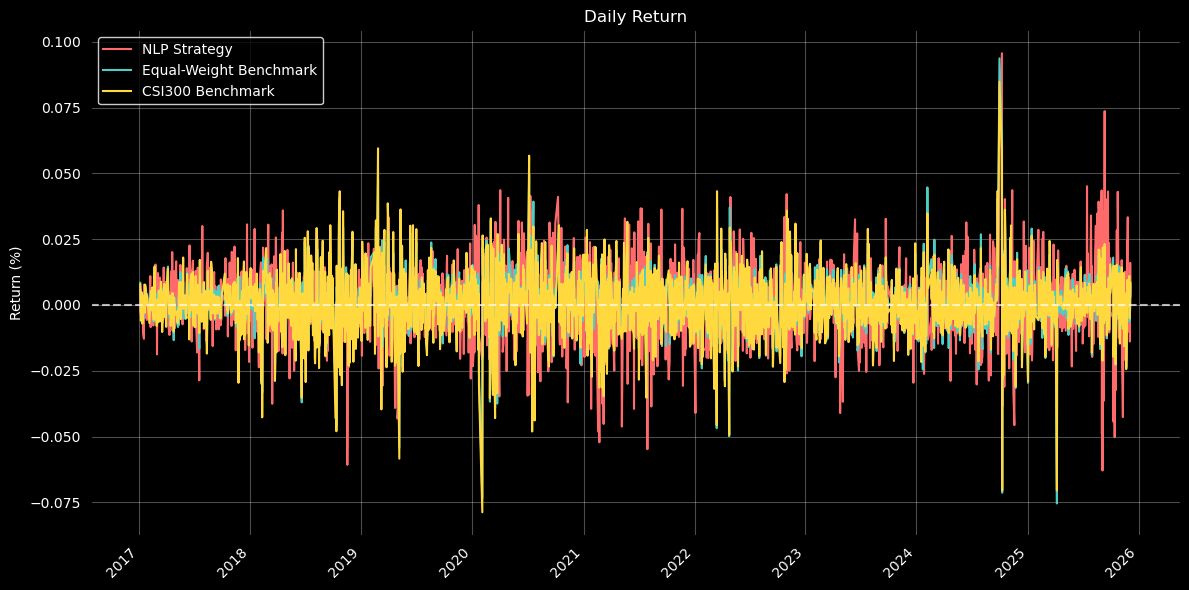

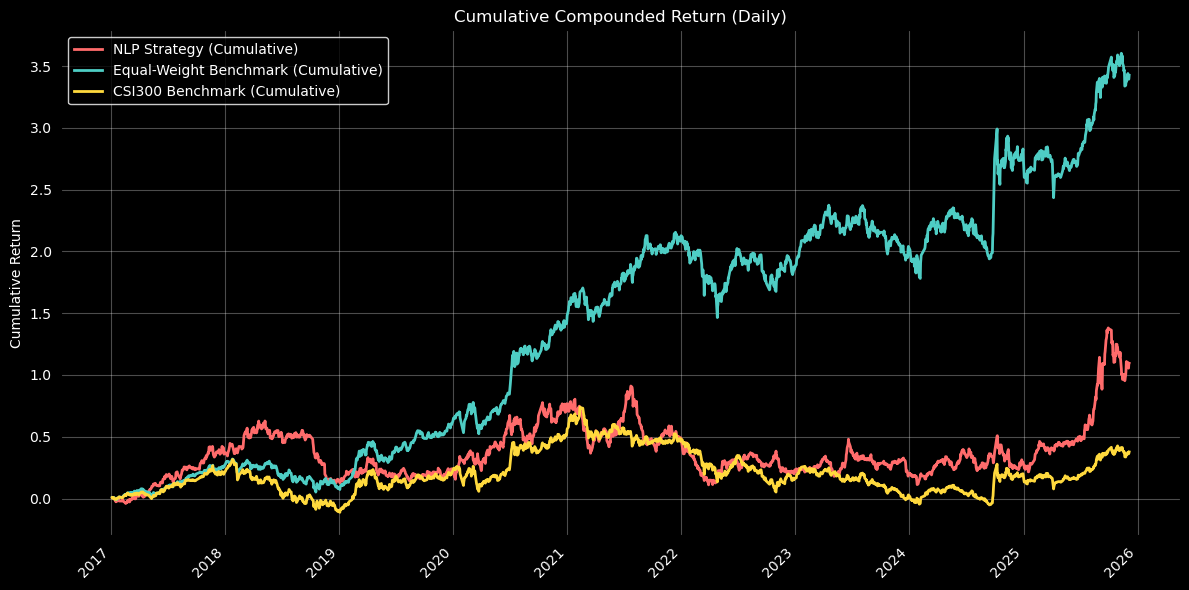

In [129]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np

# def backtest(return_data, daily_weights):
#     return daily_weights.groupby(by='date').apply(lambda x: compute_weighted_return(return_data, x))

# def compute_weighted_return(return_data, group):
#     date = group.name
#     data = return_data.loc[return_data['date'] == date, :].copy()
#     data.drop('date', axis=1, inplace=True)

#     # 如果该日没有数据，返回 NaN
#     if data.empty:
#         return np.nan

#     group = group.set_index('stock')
#     # 取该日所有股票收益率（Series）
#     returns = data.iloc[0]
#     # 权重和收益率对齐后相乘
#     weighted_return = (group['weight'] * returns).sum()
#     return weighted_return

# def visualize_all(avg_return):
#     avg_return['date'] = pd.to_datetime(avg_return['date'])

#     # Plot 1: Daily Returns
#     fig1, ax1 = plt.subplots(figsize=(12, 6))
#     fig1.patch.set_facecolor('black')
#     ax1.set_facecolor('black')

#     ax1.plot(avg_return['date'], avg_return['nlp_return'], label='NLP Strategy',
#              color='#FF6B6B', linewidth=1.5)
#     ax1.plot(avg_return['date'], avg_return['benchmark_return'], label='Equal-Weight Benchmark',
#              color='#4ECDC4', linewidth=1.5)
#     ax1.axhline(y=0, color='white', linestyle='--', alpha=0.7)
#     ax1.set_title('Daily Return', color='white')
#     ax1.set_ylabel('Return (%)', color='white')
#     legend = ax1.legend(facecolor='black', edgecolor='white')
#     for text in legend.get_texts():
#         text.set_color("white")
#     ax1.grid(True, alpha=0.3, color='white')
#     plt.xticks(rotation=45, ha='right', color='white')
#     plt.yticks(color='white')
#     plt.tight_layout()
#     plt.show()

#     # Plot 2: Cumulative Returns
#     fig2, ax2 = plt.subplots(figsize=(12, 6))
#     fig2.patch.set_facecolor('black')
#     ax2.set_facecolor('black')

#     ax2.plot(avg_return['date'], avg_return['nlp_cum_return'], label='NLP Strategy (Cumulative)',
#              color='#FF6B6B', linewidth=2.0)
#     ax2.plot(avg_return['date'], avg_return['benchmark_cum_return'], label='Equal-Weight Benchmark (Cumulative)',
#              color='#4ECDC4', linewidth=2.0)
#     ax2.set_title('Cumulative Compounded Return (Daily)', color='white')
#     ax2.set_ylabel('Cumulative Return', color='white')
#     legend = ax2.legend(facecolor='black', edgecolor='white')
#     for text in legend.get_texts():
#         text.set_color("white")
#     ax2.grid(True, alpha=0.3, color='white')
#     plt.xticks(rotation=45, ha='right', color='white')
#     plt.yticks(color='white')
#     plt.tight_layout()
#     plt.show()


# if __name__ == "__main__":
#     # === Load daily return data ===
#     re_data = pd.read_csv('all_stock_returns.csv')
#     re_data['交易日期'] = pd.to_datetime(re_data['交易日期'], format='%Y-%m-%d')
#     re_data = re_data[re_data['交易日期'] >= '2017-01-01'].reset_index(drop=True)
#     re_data.fillna(0, inplace=True)

#     # 转换成日频率表
#     d_data = re_data.copy()
#     d_data.rename(columns={'交易日期': 'date'}, inplace=True)

#     # 股票代码列补齐为6位
#     d_data.columns = [col.zfill(6) if col.isdigit() else col for col in d_data.columns]

#     # === Benchmark: Equal-weight buy-and-hold ===
#     if '沪深300' in d_data.columns:
#         d_data.drop('沪深300', axis=1, inplace=True)

#     benchmark = d_data.copy()
#     benchmark['benchmark_return'] = benchmark.drop('date', axis=1).mean(axis=1)

#     # === Load daily weights ===
#     weights = pd.read_csv('daily_weights_sentiment.csv')
#     weights['date'] = pd.to_datetime(weights['date'], format='%Y%m%d')
#     weights['stock'] = weights['stock'].astype(str).str.zfill(6)
        
#     # === Backtest NLP overlay ===
#     nlp_return = backtest(d_data, weights)
#     nlp_return.name = 'nlp_return'
#     nlp_return = nlp_return.reset_index()

#     # 合并 benchmark
#     avg_return = nlp_return.merge(benchmark[['date', 'benchmark_return']], on='date', how='inner')

#     # 转换为小数
#     avg_return['nlp_return'] = avg_return['nlp_return'] / 100
#     avg_return['benchmark_return'] = avg_return['benchmark_return'] / 100

#     # === Overlay组合 ===
#     avg_return['overlay_return'] = avg_return['benchmark_return'] + avg_return['nlp_return']

#     # 累计收益
#     avg_return['benchmark_cum_return'] = (1 + avg_return['benchmark_return']).cumprod() - 1
#     avg_return['nlp_cum_return'] = (1 + avg_return['nlp_return']).cumprod() - 1
#     avg_return['overlay_cum_return'] = (1 + avg_return['overlay_return']).cumprod() - 1

#     # === Sharpe Ratio (Annualized) ===
#     def annualized_sharpe(series):
#         mean = series.mean()
#         std = series.std()
#         daily_sharpe = mean / std if std != 0 else np.nan
#         return daily_sharpe * np.sqrt(252)

#     sharpe_bench = annualized_sharpe(avg_return['benchmark_return'])
#     sharpe_nlp = annualized_sharpe(avg_return['nlp_return'])
#     sharpe_overlay = annualized_sharpe(avg_return['overlay_return'])

#     # === Information Ratio (Annualized) ===
#     def annualized_ir(series, benchmark_series):
#         excess = series - benchmark_series
#         mean_excess = excess.mean()
#         std_excess = excess.std()
#         daily_ir = mean_excess / std_excess if std_excess != 0 else np.nan
#         return daily_ir * np.sqrt(252)

#     info_ratio_overlay = annualized_ir(avg_return['overlay_return'], avg_return['benchmark_return'])

#     print("📊 Total Cumulative Returns")
#     print(f"Benchmark - Total Return: {avg_return['benchmark_cum_return'].iloc[-1]:.2%}")
#     print(f"NLP Strategy (0-value) - Total Return: {avg_return['nlp_cum_return'].iloc[-1]:.2%}")
#     print(f"Overlay Strategy - Total Return: {avg_return['overlay_cum_return'].iloc[-1]:.2%}")

#     print("📈 Portfolio Performance Metrics (Annualized)")
#     print(f"Benchmark - Sharpe: {sharpe_bench:.4f}")
#     print(f"NLP Strategy - Sharpe: {sharpe_nlp:.4f}")
#     print(f"Overlay Strategy - Sharpe: {sharpe_overlay:.4f}")
#     print(f"Overlay Strategy - Information Ratio vs Benchmark: {info_ratio_overlay:.4f}")

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def backtest(return_data, daily_weights):
    return daily_weights.groupby(by='date').apply(lambda x: compute_weighted_return(return_data, x))

def compute_weighted_return(return_data, group):
    date = group.name
    data = return_data.loc[return_data['date'] == date, :].copy()
    data.drop('date', axis=1, inplace=True)

    # 如果该日没有数据，返回 NaN
    if data.empty:
        return np.nan

    group = group.set_index('stock')
    # 取该日所有股票收益率（Series）
    returns = data.iloc[0]
    # 权重和收益率对齐后相乘
    weighted_return = (group['weight'] * returns).sum()
    return weighted_return

def visualize_all(avg_return):
    avg_return['date'] = pd.to_datetime(avg_return['date'])

    # Plot 1: Daily Returns
    fig1, ax1 = plt.subplots(figsize=(12, 6))
    fig1.patch.set_facecolor('black')
    ax1.set_facecolor('black')

    ax1.plot(avg_return['date'], avg_return['nlp_return'], label='NLP Strategy',
             color='#FF6B6B', linewidth=1.5)
    ax1.plot(avg_return['date'], avg_return['benchmark_return'], label='Equal-Weight Benchmark',
             color='#4ECDC4', linewidth=1.5)
    ax1.plot(avg_return['date'], avg_return['csi300_return'], label='CSI300 Benchmark',
             color='#FFD93D', linewidth=1.5)
    ax1.axhline(y=0, color='white', linestyle='--', alpha=0.7)
    ax1.set_title('Daily Return', color='white')
    ax1.set_ylabel('Return (%)', color='white')
    legend = ax1.legend(facecolor='black', edgecolor='white')
    for text in legend.get_texts():
        text.set_color("white")
    ax1.grid(True, alpha=0.3, color='white')
    plt.xticks(rotation=45, ha='right', color='white')
    plt.yticks(color='white')
    plt.tight_layout()
    plt.show()

    # Plot 2: Cumulative Returns
    fig2, ax2 = plt.subplots(figsize=(12, 6))
    fig2.patch.set_facecolor('black')
    ax2.set_facecolor('black')

    ax2.plot(avg_return['date'], avg_return['nlp_cum_return'], label='NLP Strategy (Cumulative)',
             color='#FF6B6B', linewidth=2.0)
    ax2.plot(avg_return['date'], avg_return['benchmark_cum_return'], label='Equal-Weight Benchmark (Cumulative)',
             color='#4ECDC4', linewidth=2.0)
    ax2.plot(avg_return['date'], avg_return['csi300_cum_return'], label='CSI300 Benchmark (Cumulative)',
             color='#FFD93D', linewidth=2.0)
    ax2.set_title('Cumulative Compounded Return (Daily)', color='white')
    ax2.set_ylabel('Cumulative Return', color='white')
    legend = ax2.legend(facecolor='black', edgecolor='white')
    for text in legend.get_texts():
        text.set_color("white")
    ax2.grid(True, alpha=0.3, color='white')
    plt.xticks(rotation=45, ha='right', color='white')
    plt.yticks(color='white')
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # === Load daily return data ===
    re_data = pd.read_csv('all_stock_returns.csv')
    re_data['交易日期'] = pd.to_datetime(re_data['交易日期'], format='%Y-%m-%d')
    re_data = re_data[re_data['交易日期'] >= '2017-01-01'].reset_index(drop=True)
    re_data.fillna(0, inplace=True)

    # 转换成日频率表
    d_data = re_data.copy()
    d_data.rename(columns={'交易日期': 'date'}, inplace=True)

    # 股票代码列补齐为6位
    d_data.columns = [col.zfill(6) if col.isdigit() else col for col in d_data.columns]

    # === Benchmark: Equal-weight buy-and-hold ===
    benchmark = d_data.copy()
    benchmark['benchmark_return'] = benchmark.drop(['date','沪深300'], axis=1).mean(axis=1)

    # === CSI300 Benchmark ===
    benchmark['csi300_return'] = benchmark['沪深300']

    # === Load daily weights ===
    weights = pd.read_csv('daily_weights_sentiment.csv')
    weights['date'] = pd.to_datetime(weights['date'], format='%Y%m%d')
    weights['stock'] = weights['stock'].astype(str).str.zfill(6)
        
    # === Backtest NLP overlay ===
    nlp_return = backtest(d_data, weights)
    nlp_return.name = 'nlp_return'
    nlp_return = nlp_return.reset_index()

    # 合并 benchmark 和 CSI300
    avg_return = nlp_return.merge(
        benchmark[['date', 'benchmark_return', 'csi300_return']],
        on='date', how='inner'
    )

    # 转换为小数
    avg_return['nlp_return'] = avg_return['nlp_return'] / 100
    avg_return['benchmark_return'] = avg_return['benchmark_return'] / 100
    avg_return['csi300_return'] = avg_return['csi300_return'] / 100

    # === Overlay组合 ===
    avg_return['overlay_return'] = avg_return['benchmark_return'] + avg_return['nlp_return']

    # 累计收益
    avg_return['benchmark_cum_return'] = (1 + avg_return['benchmark_return']).cumprod() - 1
    avg_return['csi300_cum_return'] = (1 + avg_return['csi300_return']).cumprod() - 1
    avg_return['nlp_cum_return'] = (1 + avg_return['nlp_return']).cumprod() - 1
    avg_return['overlay_cum_return'] = (1 + avg_return['overlay_return']).cumprod() - 1

    # === Sharpe Ratio (Annualized) ===
    def annualized_sharpe(series):
        mean = series.mean()
        std = series.std()
        daily_sharpe = mean / std if std != 0 else np.nan
        return daily_sharpe * np.sqrt(252)

    sharpe_bench = annualized_sharpe(avg_return['benchmark_return'])
    sharpe_csi300 = annualized_sharpe(avg_return['csi300_return'])
    sharpe_nlp = annualized_sharpe(avg_return['nlp_return'])
    sharpe_overlay = annualized_sharpe(avg_return['overlay_return'])

    # === Information Ratio (Annualized) ===
    def annualized_ir(series, benchmark_series):
        excess = series - benchmark_series
        mean_excess = excess.mean()
        std_excess = excess.std()
        daily_ir = mean_excess / std_excess if std_excess != 0 else np.nan
        return daily_ir * np.sqrt(252)

    info_ratio_overlay = annualized_ir(avg_return['overlay_return'], avg_return['benchmark_return'])
    info_ratio_nlp= annualized_ir(avg_return['nlp_return'], avg_return['benchmark_return'])

    print("📊 Total Cumulative Returns")
    print(f"Equal-Weight Benchmark - Total Return: {avg_return['benchmark_cum_return'].iloc[-1]:.2%}")
    print(f"CSI300 Benchmark - Total Return: {avg_return['csi300_cum_return'].iloc[-1]:.2%}")
    print(f"NLP Strategy - Total Return: {avg_return['nlp_cum_return'].iloc[-1]:.2%}")
    print(f"Overlay Strategy - Total Return: {avg_return['overlay_cum_return'].iloc[-1]:.2%}")

    print("📈 Portfolio Performance Metrics (Annualized)")
    print(f"Equal-Weight Benchmark - Sharpe: {sharpe_bench:.4f}")
    print(f"CSI300 Benchmark - Sharpe: {sharpe_csi300:.4f}")
    print(f"NLP Strategy - Sharpe: {sharpe_nlp:.4f}")
    print(f"Overlay Strategy - Sharpe: {sharpe_overlay:.4f}")
    print(f"Overlay Strategy - Information Ratio vs Equal-Weight Benchmark: {info_ratio_overlay:.4f}")
    print(f"NLP Strategy - Information Ratio vs Equal-Weight Benchmark: {info_ratio_nlp:.4f}")

    # === Visualization ===
    visualize_all(avg_return)


In [101]:
avg_return

,date,nlp_return,benchmark_return,csi300_return,overlay_return,benchmark_cum_return,csi300_cum_return,nlp_cum_return,overlay_cum_return
0,2017-01-04,0.006503,0.008424,0.0078,0.014927,0.008424,0.007800,0.006503,0.014927
1,2017-01-05,-0.003038,0.000578,-0.0002,-0.002460,0.009007,0.007598,0.003446,0.012431
2,2017-01-06,0.005687,-0.004212,-0.0060,0.001475,0.004757,0.001553,0.009153,0.013924
3,2017-01-09,-0.003921,0.004407,0.0048,0.000486,0.009185,0.006360,0.005195,0.014417
4,2017-01-10,-0.003600,-0.002062,-0.0017,-0.005662,0.007104,0.004649,0.001577,0.008673
...,...,...,...,...,...,...,...,...,...
2162,2025-12-01,-0.003795,0.010790,0.0110,0.006996,3.440883,0.374645,1.096671,7.524630
2163,2025-12-02,-0.005987,-0.006299,-0.0048,-0.012286,3.412908,0.368047,1.084118,7.419892
2164,2025-12-03,-0.013890,-0.003768,-0.0051,-0.017657,3.396281,0.361070,1.055170,7.271220
2165,2025-12-04,0.015988,-0.000236,0.0034,0.015752,3.395242,0.365698,1.088029,7.401507


=== 股票 000002 的历史权重变化 ===
             date   stock name  weight_change
298    2017-01-04  000002  万科A            0.0
598    2017-01-05  000002  万科A            0.0
898    2017-01-06  000002  万科A            0.0
1198   2017-01-09  000002  万科A            0.0
1498   2017-01-10  000002  万科A            0.0
...           ...     ...  ...            ...
160798 2025-12-02  000002  万科A            0.0
161098 2025-12-03  000002  万科A            0.0
161398 2025-12-04  000002  万科A            0.0
161698 2025-12-05  000002  万科A            0.0
161998 2025-12-06  000002  万科A            0.0

[540 rows x 4 columns]


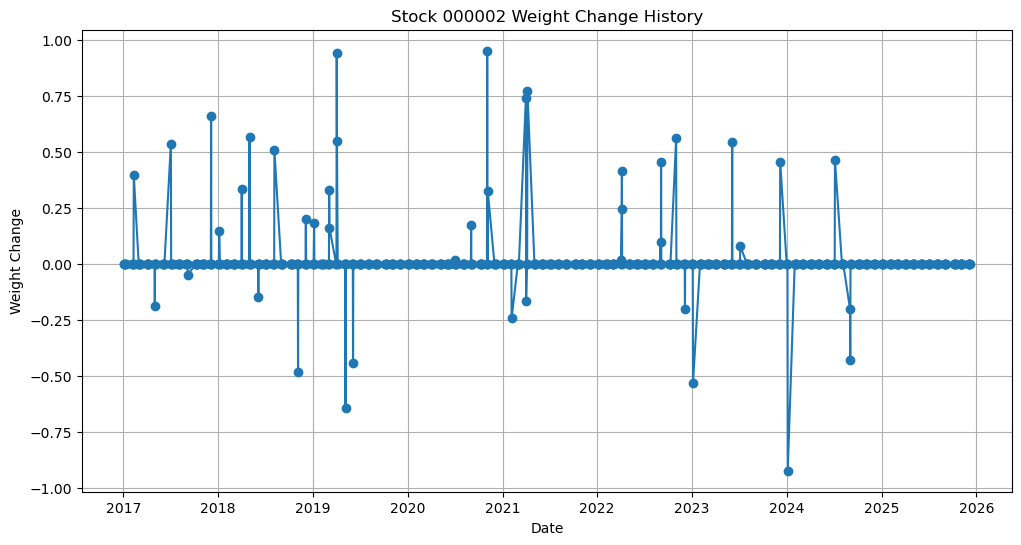

In [131]:
import pandas as pd

# 读取权重变化表
df = pd.read_csv("weight_change_daily.csv")

# 确保日期列是 datetime 格式
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')

# 股票代码补齐为6位
df['stock'] = df['stock'].astype(str).str.zfill(6)

# 筛选出股票600111的历史记录
stock_code = "000002"
stock_history = df[df['stock'] == stock_code].sort_values(by="date")

# 输出结果
print(f"=== 股票 {stock_code} 的历史权重变化 ===")
print(stock_history[['date', 'stock', 'name', 'weight_change']])

stock_history.to_csv(f'stock_{stock_code}_weight_change_history.csv', index=False)
# 如果想画图，可以加上：
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(stock_history['date'], stock_history['weight_change'], marker='o')
plt.title(f"Stock {stock_code} Weight Change History")
plt.xlabel("Date")
plt.ylabel("Weight Change")
plt.grid(True)
plt.show()


In [132]:
import pandas as pd

# 读取 daily_weights_sentiment.csv
weights = pd.read_csv("daily_weights_sentiment.csv", dtype=str)

# 转换日期列为 datetime
weights['date'] = pd.to_datetime(weights['date'], errors='coerce')

# 转换数值列为 float
for col in ['weight_change', 'weight']:
    if col in weights.columns:
        weights[col] = pd.to_numeric(weights[col], errors='coerce')

# 检查缺失情况
missing_report = weights.isna().sum().to_frame(name="missing_count")
missing_report["total_count"] = len(weights)
missing_report["missing_ratio"] = missing_report["missing_count"] / missing_report["total_count"]

print("=== 缺失值检查报告 ===")
print(missing_report)

# 额外检查：哪些行有缺失
rows_with_missing = weights[weights.isna().any(axis=1)]
print("\n=== 存在缺失的行样例 ===")
print(rows_with_missing.head(10))


=== 缺失值检查报告 ===
           missing_count  total_count  missing_ratio
date                   0        65473            0.0
stock                  0        65473            0.0
name                   0        65473            0.0
sentiment              0        65473            0.0
weight                 0        65473            0.0

=== 存在缺失的行样例 ===
Empty DataFrame
Columns: [date, stock, name, sentiment, weight]
Index: []


In [104]:
avg_return['nlp_cum_return']

0       0.006503
1       0.003446
2       0.009153
3       0.005195
4       0.001577
          ...   
2162    1.096671
2163    1.084118
2164    1.055170
2165    1.088029
2166    1.094799
Name: nlp_cum_return, Length: 2167, dtype: float64

In [105]:
avg_return['nlp_cum_return'].count()

np.int64(2167)

In [106]:
avg_return['nlp_cum_return'].isna().sum()

np.int64(0)

In [126]:
weights = pd.read_csv('daily_weights_sentiment.csv')
weights.groupby(by='date').sum('weight')

,stock,sentiment,weight
date,,,
20170104,126606676,1.700660,2.462223e-14
20170105,2702452,0.750124,0.000000e+00
20170106,2702452,0.706105,0.000000e+00
20170107,2702452,0.706105,0.000000e+00
20170108,2702452,0.706105,0.000000e+00
...,...,...,...
20251207,8595221,0.354314,0.000000e+00
20251208,8595221,0.354314,0.000000e+00
20251209,8595221,0.354314,0.000000e+00


In [135]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def backtest(return_data, daily_weights):
    return daily_weights.groupby(by='date').apply(lambda x: compute_weighted_return(return_data, x))

def compute_weighted_return(return_data, group):
    date = group.name
    data = return_data.loc[return_data['date'] == date, :].copy()
    data.drop('date', axis=1, inplace=True)

    if data.empty:
        return np.nan

    group = group.set_index('stock')
    returns = data.iloc[0]
    weighted_return = (group['weight'] * returns).sum()
    return weighted_return

def visualize_all(avg_return, sharpe_bench, sharpe_csi300, sharpe_nlp, sharpe_overlay,
                  info_ratio_overlay, info_ratio_nlp_vs_csi300):
    avg_return['date'] = pd.to_datetime(avg_return['date'])

    # Plot 1: Daily Returns
    fig1, ax1 = plt.subplots(figsize=(12, 6))
    fig1.patch.set_facecolor('black')
    ax1.set_facecolor('black')

    ax1.plot(avg_return['date'], avg_return['nlp_return'], label='NLP Strategy',
             color='#FF6B6B', linewidth=1.5)
    ax1.plot(avg_return['date'], avg_return['benchmark_return'], label='Equal-Weight Benchmark',
             color='#4ECDC4', linewidth=1.5)
    ax1.plot(avg_return['date'], avg_return['csi300_return'], label='CSI300 Benchmark',
             color='#FFD93D', linewidth=1.5)
    ax1.plot(avg_return['date'], avg_return['overlay_return'], label='Overlay Strategy',
             color='#A29BFE', linewidth=1.5)
    ax1.axhline(y=0, color='white', linestyle='--', alpha=0.7)
    ax1.set_title('Daily Return Comparison', color='white')
    ax1.set_ylabel('Return (%)', color='white')
    legend = ax1.legend(facecolor='black', edgecolor='white')
    for text in legend.get_texts():
        text.set_color("white")
    ax1.grid(True, alpha=0.3, color='white')
    plt.xticks(rotation=45, ha='right', color='white')
    plt.yticks(color='white')
    plt.tight_layout()
    plt.show()

    # Plot 2: Cumulative Returns
    fig2, ax2 = plt.subplots(figsize=(12, 6))
    fig2.patch.set_facecolor('black')
    ax2.set_facecolor('black')

    ax2.plot(avg_return['date'], avg_return['nlp_cum_return'], label='NLP Strategy (Cumulative)',
             color='#FF6B6B', linewidth=2.0)
    ax2.plot(avg_return['date'], avg_return['benchmark_cum_return'], label='Equal-Weight Benchmark (Cumulative)',
             color='#4ECDC4', linewidth=2.0)
    ax2.plot(avg_return['date'], avg_return['csi300_cum_return'], label='CSI300 Benchmark (Cumulative)',
             color='#FFD93D', linewidth=2.0)
    ax2.plot(avg_return['date'], avg_return['overlay_cum_return'], label='Overlay Strategy (Cumulative)',
             color='#A29BFE', linewidth=2.0)
    ax2.set_title('Cumulative Compounded Return (Daily)', color='white')
    ax2.set_ylabel('Cumulative Return', color='white')
    legend = ax2.legend(facecolor='black', edgecolor='white')
    for text in legend.get_texts():
        text.set_color("white")
    ax2.grid(True, alpha=0.3, color='white')
    plt.xticks(rotation=45, ha='right', color='white')
    plt.yticks(color='white')
    plt.tight_layout()
    plt.show()

    # Plot 3: Sharpe Ratio Comparison
    fig3, ax3 = plt.subplots(figsize=(8, 6))
    metrics = ['Equal-Weight', 'CSI300', 'NLP Strategy', 'Overlay']
    values = [sharpe_bench, sharpe_csi300, sharpe_nlp, sharpe_overlay]
    ax3.bar(metrics, values, color=['#4ECDC4', '#FFD93D', '#FF6B6B', '#A29BFE'])
    ax3.set_title('Annualized Sharpe Ratio Comparison')
    ax3.set_ylabel('Sharpe Ratio')
    plt.tight_layout()
    plt.show()

    # Plot 4: Information Ratio Comparison
    fig4, ax4 = plt.subplots(figsize=(8, 6))
    metrics_ir = ['Overlay vs Equal-Weight', 'NLP vs Equal-Weight']
    values_ir = [info_ratio_overlay, info_ratio_nlp]
    ax4.bar(metrics_ir, values_ir, color=['#A29BFE', '#FF6B6B'])
    ax4.set_title('Annualized Information Ratio Comparison')
    ax4.set_ylabel('Information Ratio')
    plt.tight_layout()
    plt.show()

    # Plot 5: Return Distribution Histogram
    fig5, ax5 = plt.subplots(figsize=(10, 6))
    ax5.hist(avg_return['nlp_return'], bins=50, alpha=0.6, label='NLP Strategy', color='#FF6B6B')
    ax5.hist(avg_return['benchmark_return'], bins=50, alpha=0.6, label='Equal-Weight Benchmark', color='#4ECDC4')
    ax5.hist(avg_return['csi300_return'], bins=50, alpha=0.6, label='CSI300 Benchmark', color='#FFD93D')
    ax5.hist(avg_return['overlay_return'], bins=50, alpha=0.6, label='Overlay Strategy', color='#A29BFE')
    ax5.set_title('Return Distribution Histogram')
    ax5.set_xlabel('Daily Return')
    ax5.set_ylabel('Frequency')
    ax5.legend()
    plt.tight_layout()
    plt.show()


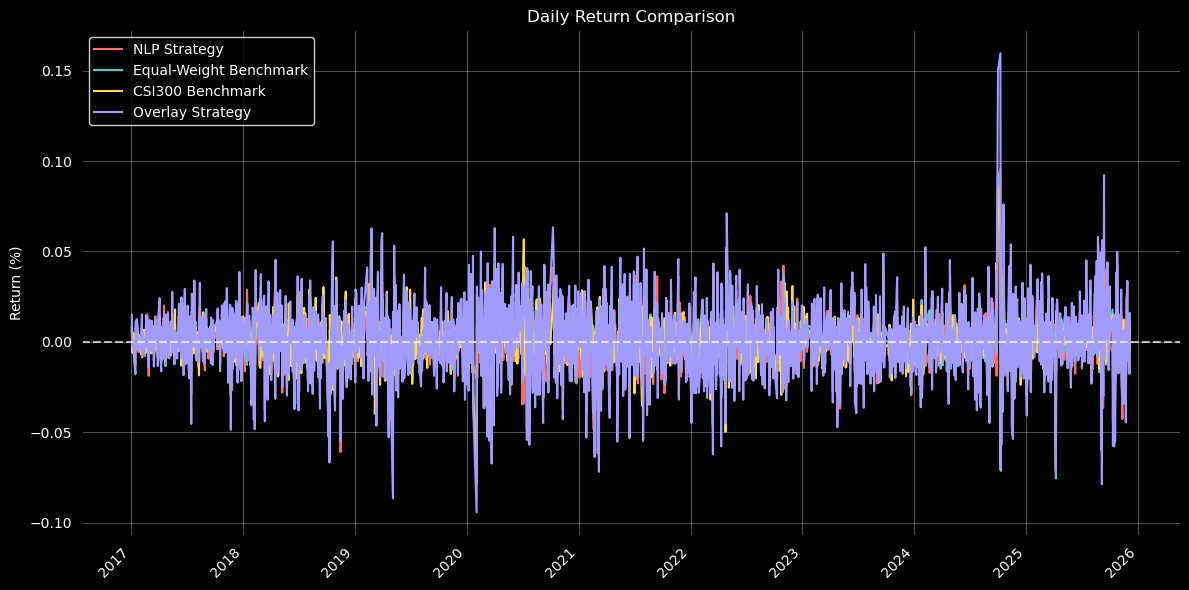

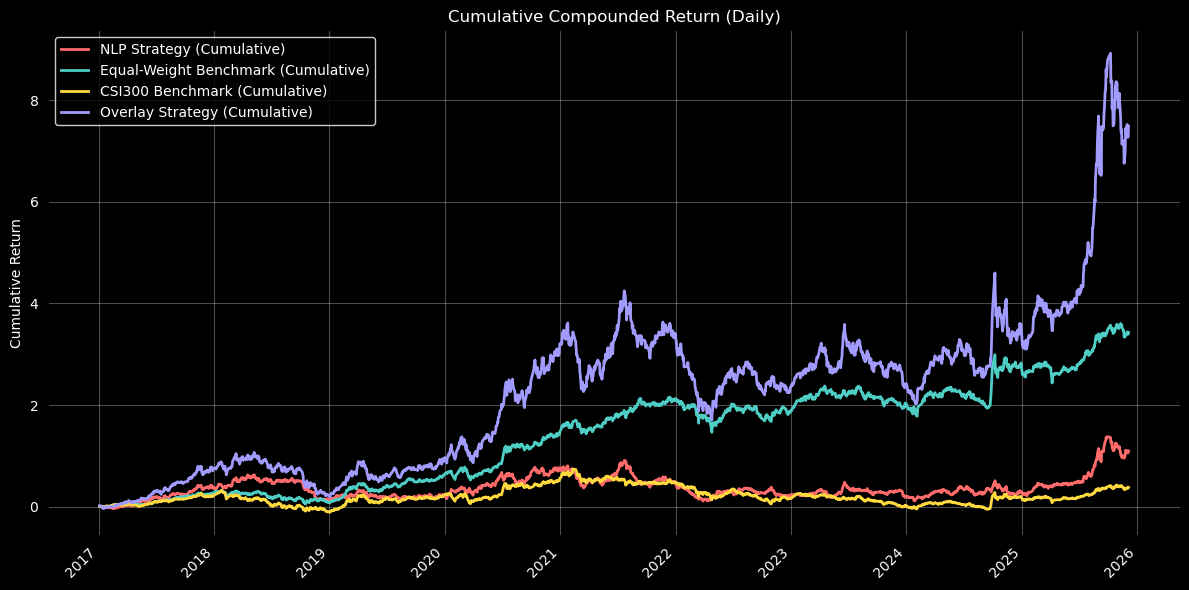

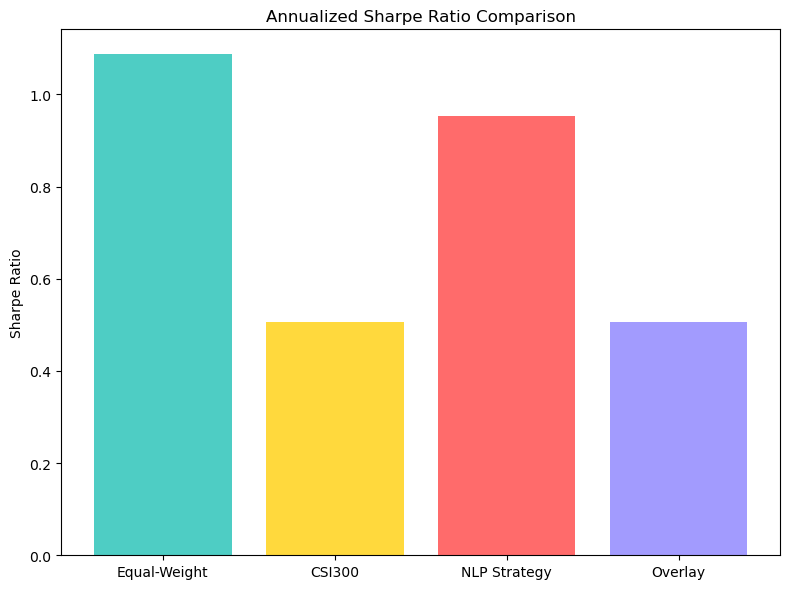

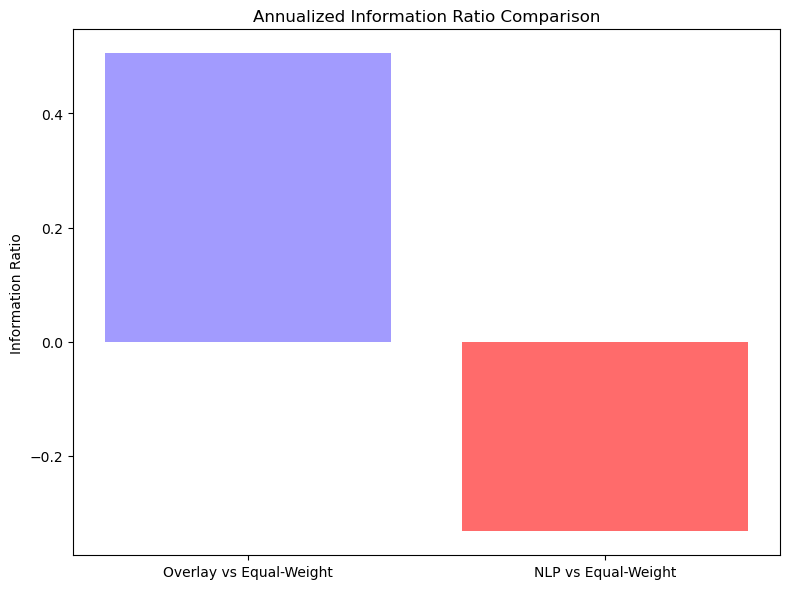

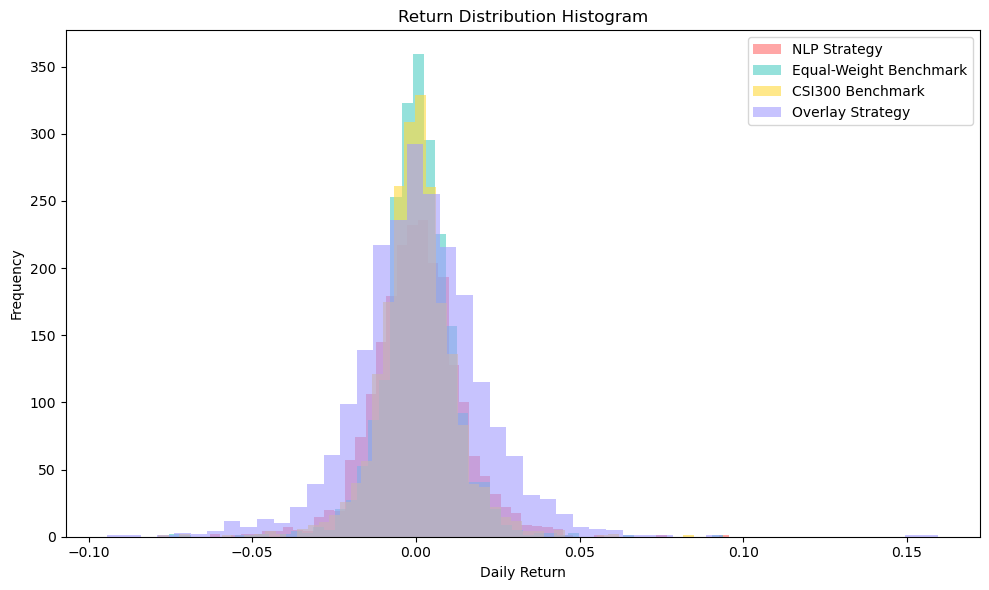

In [136]:
visualize_all( avg_return, sharpe_bench, sharpe_nlp, sharpe_overlay, info_ratio_overlay, info_ratio_overlay, info_ratio_nlp_vs_csi300)

In [137]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
# 假设 re_data 已经加载，包含 '交易日期' 和各股票列
# 假设 avg_return 已经计算，包含 'nlp_return'

# 转换日期
re_data['交易日期'] = pd.to_datetime(re_data['交易日期'])
re_data.rename(columns={'交易日期': 'date'}, inplace=True)

# 股票收益矩阵
stock_returns = re_data.set_index('date')

# NLP long-short 因子
factor = avg_return[['date', 'nlp_return']].set_index('date')


In [138]:
def clean_series(y, factor):
    """
    清理个股收益率序列：
    - 剔除停牌/未发行日 (收益=0 且因子非零)
    - 剔除 NaN
    """
    df = pd.concat([y, factor], axis=1, join='inner')
    df.columns = ['stock_return', 'nlp_return']
    # 剔除停牌日：收益=0 且因子!=0
    df = df[~((df['stock_return'] == 0) & (df['nlp_return'] != 0))]
    # 剔除 NaN
    df = df.dropna()
    return df


In [140]:

results = {}
for stock in stock_returns.columns:
    y = stock_returns[stock].astype(float)   # 强制转换为 float
    df = clean_series(y, factor['nlp_return'].astype(float))
    if len(df) > 50:  # 至少有足够样本
        X = sm.add_constant(df['nlp_return'].astype(float))
        y_clean = df['stock_return'].astype(float)/100
        model = sm.OLS(y_clean.values, X.values).fit()  # 用 .values 保证是纯 numpy 数组
        results[stock] = {
            'alpha': model.params[0],        # const
            'beta': model.params[1],         # nlp_return
            'r2': model.rsquared
        }
        print(model.summary())  # 可选：打印回归结果

ols_results = pd.DataFrame(results).T
ols_results.sort_values('r2', ascending=False, inplace=True)
ols_results.head(10)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     12.25
Date:                Mon, 09 Feb 2026   Prob (F-statistic):           0.000481
Time:                        23:23:00   Log-Likelihood:                 1758.4
No. Observations:                1293   AIC:                            -3513.
Df Residuals:                    1291   BIC:                            -3503.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0020      0.002      1.169      0.2

,alpha,beta,r2
603296,0.000584,0.838822,0.168991
300502,0.002032,1.090372,0.135575
300308,0.002005,0.957747,0.131624
600588,0.000264,0.794171,0.126505
000977,0.000763,0.817897,0.125095
688041,0.002463,1.153119,0.124697
603019,0.001045,0.791848,0.118562
300394,0.001811,0.974002,0.114441
002463,0.001486,0.790524,0.112602
002371,0.001665,0.810824,0.111943


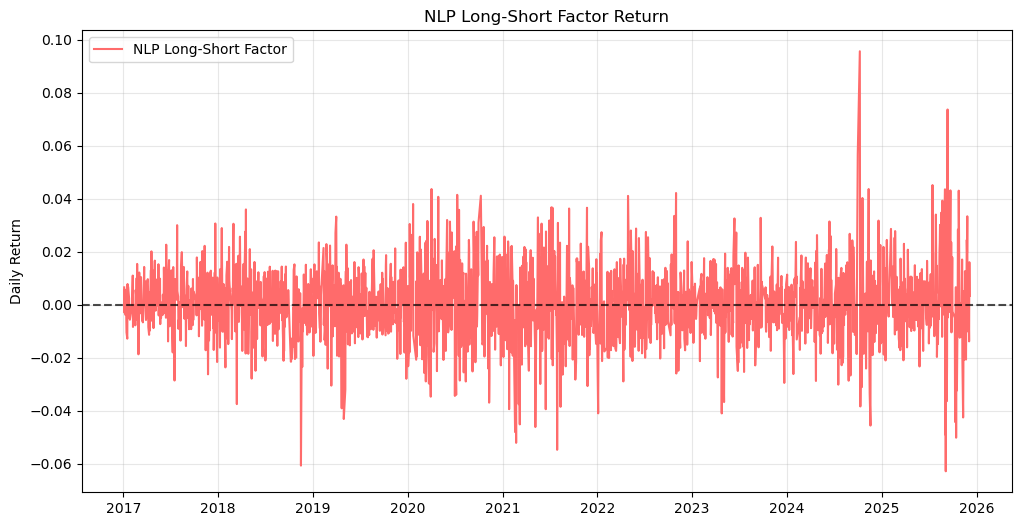

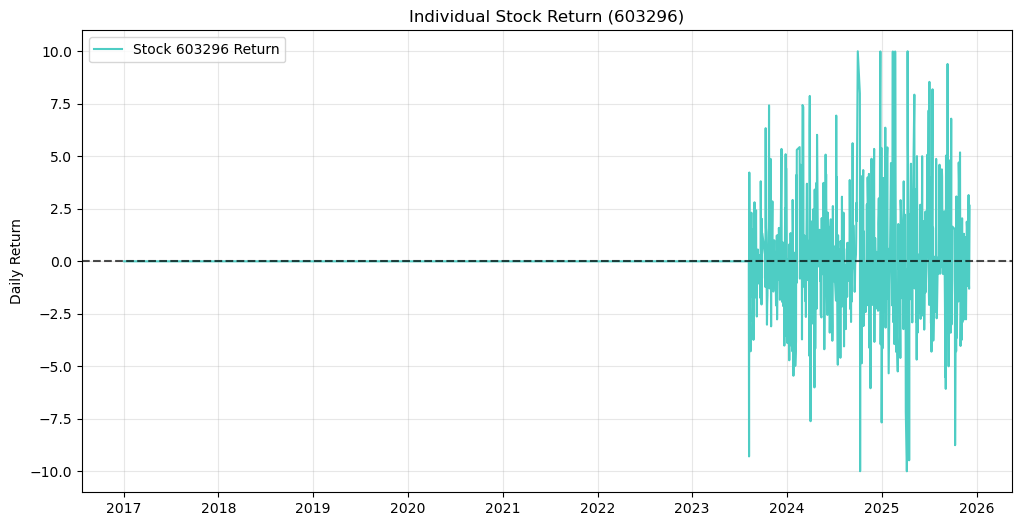

In [141]:
# 图1: NLP因子收益率
plt.figure(figsize=(12,6))
plt.plot(factor.index, factor['nlp_return'], color='#FF6B6B', label='NLP Long-Short Factor')
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title('NLP Long-Short Factor Return')
plt.ylabel('Daily Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 图2: 个股收益率示例 (取R²最高的股票)
top_stock = ols_results.index[0]
plt.figure(figsize=(12,6))
plt.plot(stock_returns.index, stock_returns[top_stock], color='#4ECDC4', label=f'Stock {top_stock} Return')
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title(f'Individual Stock Return ({top_stock})')
plt.ylabel('Daily Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [142]:
# 因子组合收益率 (y)
y = avg_return['nlp_return'].astype(float)

# 市场基准收益率 (X)
X = sm.add_constant(avg_return['csi300_return'].astype(float))

# OLS 回归
model = sm.OLS(y.values, X.values).fit()

# 打印回归结果
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.071
Method:                 Least Squares   F-statistic:                     166.9
Date:                Mon, 09 Feb 2026   Prob (F-statistic):           7.76e-37
Time:                        23:23:07   Log-Likelihood:                 6313.6
No. Observations:                2167   AIC:                        -1.262e+04
Df Residuals:                    2165   BIC:                        -1.261e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      1.299      0.1

In [143]:
alpha = model.params[0]   # 截距项 (alpha)
beta = model.params[1]    # 因子对市场的敏感度
r2 = model.rsquared       # 解释率

print(f"Alpha (超额收益): {alpha:.6f}")
print(f"Beta (市场暴露): {beta:.4f}")
print(f"R² (解释率): {r2:.4f}")


Alpha (超额收益): 0.000367
Beta (市场暴露): 0.3105
R² (解释率): 0.0716


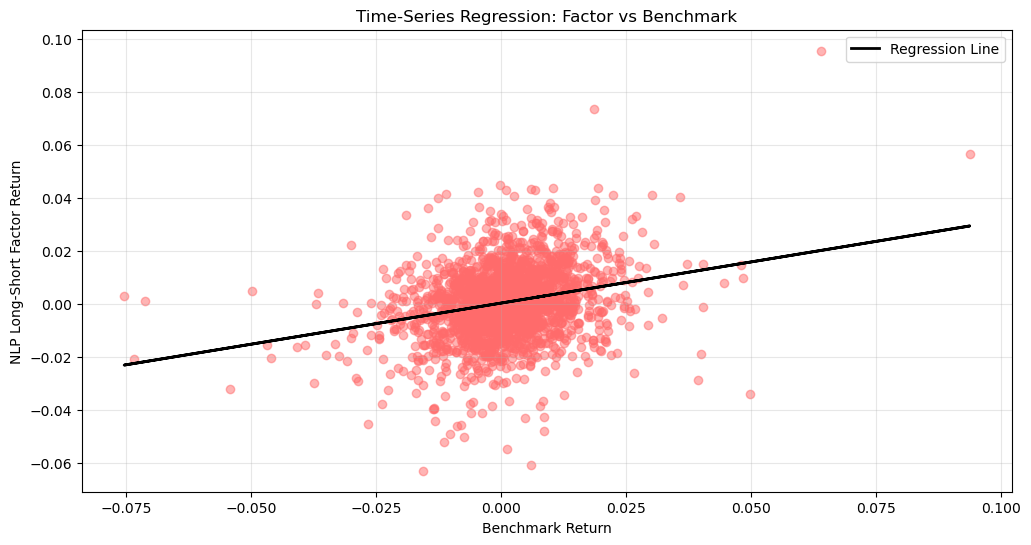

In [144]:
plt.figure(figsize=(12,6))
plt.scatter(avg_return['benchmark_return'], avg_return['nlp_return'], alpha=0.5, color='#FF6B6B')
plt.xlabel("Benchmark Return")
plt.ylabel("NLP Long-Short Factor Return")
plt.title("Time-Series Regression: Factor vs Benchmark")

# 回归线
x_vals = avg_return['benchmark_return']
y_pred = model.params[0] + model.params[1] * x_vals
plt.plot(x_vals, y_pred, color='black', linewidth=2, label='Regression Line')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


ℹ️ Daily gross leverage median=0.0000, max=2.0000
ℹ️ Net weight max abs=2.482736e-14
ℹ️ Active gross leverage median=2.0000, min=1.0000, max=2.0000
⚠️ Gross leverage not near 2 on 8 active days (show first 10):
date
2017-01-05    1.0
2017-01-06    1.0
2017-01-09    1.0
2017-01-10    1.0
2017-01-11    1.0
2017-01-12    1.0
2017-01-13    1.0
2017-01-16    1.0
dtype: float64
✅ 日度回测结果已保存: backtest_daily_model_weight.csv
✅ 绩效汇总已保存: backtest_summary_model_weight.csv
✅ Execution lag days: 1 (forward look bias mitigated)


,portfolio_ann_return,portfolio_ann_vol,portfolio_sharpe,portfolio_max_drawdown,portfolio_win_rate,benchmark_ann_return,benchmark_ann_vol,benchmark_sharpe,benchmark_max_drawdown,benchmark_win_rate,excess_ann_return,excess_ann_vol,excess_sharpe,excess_max_drawdown,excess_win_rate
0,0.036932,0.096247,0.383722,-0.327945,0.182556,0.063075,0.227092,0.277751,-0.723033,0.423683,-0.072296,0.240533,-0.300564,-0.932095,0.391692


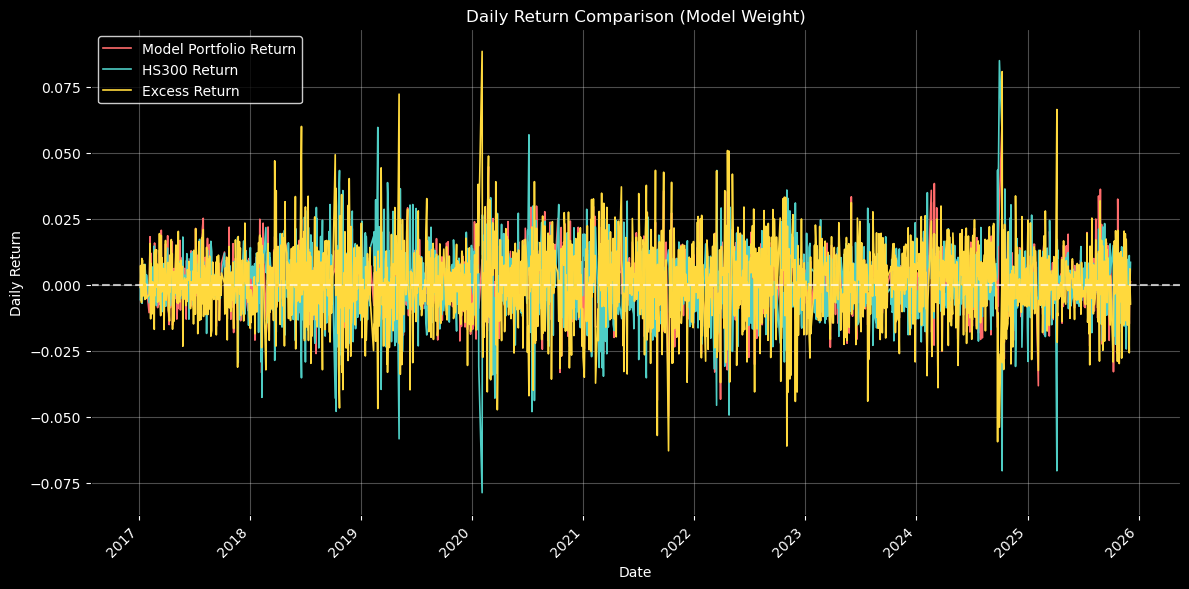

C:\Users\Administrator\AppData\Local\Temp\ipykernel_346284\2525166421.py:357: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cap_df.loc[bad_mask, '交易日期'] = pd.to_datetime(date_raw[bad_mask], errors='coerce')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_346284\2525166421.py:357: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cap_df.loc[bad_mask, '交易日期'] = pd.to_datetime(date_raw[bad_mask], errors='coerce')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_346284\2525166421.py:357: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cap_df.loc[bad_mask, '交易日期'] = pd.to_datet

ℹ️ Value-weighted constituents used: 291 (t-1 market-cap weights)


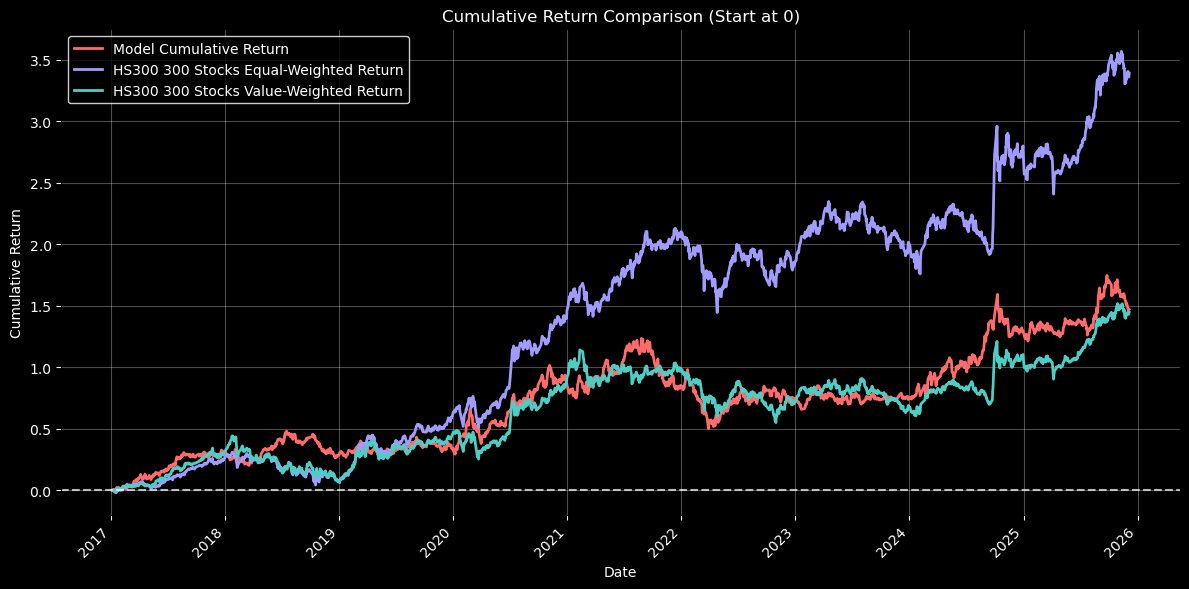

In [42]:
# ===== 新增Cell：回测 daily_weights_finbert_base.csv 的 long-short 策略（已处理 forward look bias） =====

import os

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt


# 1) 参数

WEIGHT_FILE = "daily_weights_finbert_base.csv"

RETURNS_FILE = "all_stock_returns.csv"

OUT_DAILY_FILE = "backtest_daily_model_weight.csv"

OUT_SUMMARY_FILE = "backtest_summary_model_weight.csv"

TRADING_DAYS_PER_YEAR = 252

EXECUTION_LAG_DAYS = 1  # 关键：用 t-1 权重交易 t 日收益，避免 forward look bias


# 2) 读取数据

if not os.path.exists(WEIGHT_FILE):

    raise FileNotFoundError(f"未找到权重文件: {WEIGHT_FILE}")

if not os.path.exists(RETURNS_FILE):

    raise FileNotFoundError(f"未找到收益率文件: {RETURNS_FILE}")


w = pd.read_csv(WEIGHT_FILE)

r = pd.read_csv(RETURNS_FILE)


required_w_cols = {"date", "stock", "weight"}

if not required_w_cols.issubset(w.columns):

    raise ValueError(f"权重文件缺少列: {required_w_cols}")

if "交易日期" not in r.columns:

    raise ValueError("收益率文件必须包含列: 交易日期")


w["date"] = pd.to_datetime(w["date"].astype(str), format="%Y%m%d", errors="coerce")

w["stock"] = w["stock"].astype(str).str.zfill(6)

w["weight"] = pd.to_numeric(w["weight"], errors="coerce")

w = w.dropna(subset=["date", "stock", "weight"])


r["交易日期"] = pd.to_datetime(r["交易日期"], errors="coerce")

r = r.dropna(subset=["交易日期"]).sort_values("交易日期").reset_index(drop=True)


# 收益率转数值（百分比 -> 小数）

for col in r.columns:

    if col == "交易日期":

        continue

    r[col] = pd.to_numeric(r[col], errors="coerce") / 100.0


# 3) 构建权重矩阵（date x stock）

w_pivot = w.pivot_table(index="date", columns="stock", values="weight", aggfunc="mean")

w_pivot = w_pivot.sort_index()
w_pivot = w_pivot.fillna(0.0)  # 关键修复：调仓日未出现的股票应为 0，避免历史仓位被错误延续


# 4) 对齐到交易日，并前值填充（无权重日沿用上一日）

trading_dates = r["交易日期"].sort_values().unique()

w_on_trade = w_pivot.reindex(trading_dates).ffill().fillna(0.0)

w_on_trade.index = pd.to_datetime(w_on_trade.index)

# 杠杆体检：若出现异常高的 gross leverage，通常是权重处理有误
daily_gross = w_on_trade.abs().sum(axis=1)
print(f"ℹ️ Daily gross leverage median={daily_gross.median():.4f}, max={daily_gross.max():.4f}")


# 4.1 执行时滞：使用前一交易日权重

if EXECUTION_LAG_DAYS > 0:

    w_on_trade = w_on_trade.shift(EXECUTION_LAG_DAYS).fillna(0.0)


# 5) 取权重中涉及到的股票收益率

stocks_in_weight = [c for c in w_on_trade.columns if c in r.columns]

if len(stocks_in_weight) == 0:

    raise ValueError("权重股票代码与收益率文件列未匹配，请检查 stock code 格式")


ret_mat = r.set_index("交易日期")[stocks_in_weight].reindex(w_on_trade.index).fillna(0.0)

w_on_trade = w_on_trade[stocks_in_weight]
daily_net = w_on_trade.sum(axis=1)
daily_gross_after = w_on_trade.abs().sum(axis=1)
print(f"ℹ️ Net weight max abs={daily_net.abs().max():.6e}")
active_days = daily_gross_after > 1e-12
if active_days.any():
    active_gross = daily_gross_after[active_days]
    print(f"ℹ️ Active gross leverage median={active_gross.median():.4f}, min={active_gross.min():.4f}, max={active_gross.max():.4f}")
    abnormal_days = active_gross[(active_gross < 1.999999) | (active_gross > 2.000001)]
    if len(abnormal_days) > 0:
        print(f"⚠️ Gross leverage not near 2 on {len(abnormal_days)} active days (show first 10):")
        print(abnormal_days.head(10))
else:
    print("ℹ️ No active trading days after alignment/lag.")


# 组合日收益：sum(weight_i * return_i)

portfolio_ret = (w_on_trade * ret_mat).sum(axis=1)


# 基准收益（若存在沪深300列）

if "沪深300" in r.columns:

    benchmark_ret = r.set_index("交易日期").reindex(w_on_trade.index)["沪深300"].fillna(0.0)

else:

    benchmark_ret = pd.Series(0.0, index=w_on_trade.index)


excess_ret = portfolio_ret - benchmark_ret


# 6) 绩效函数

def max_drawdown(cum_nav: pd.Series) -> float:

    running_max = cum_nav.cummax()

    dd = cum_nav / running_max - 1.0

    return float(dd.min())


def perf_stats(daily_ret: pd.Series, prefix: str = "strategy") -> dict:

    daily_ret = daily_ret.dropna()

    if len(daily_ret) == 0:

        return {

            f"{prefix}_ann_return": np.nan,

            f"{prefix}_ann_vol": np.nan,

            f"{prefix}_sharpe": np.nan,

            f"{prefix}_max_drawdown": np.nan,

            f"{prefix}_win_rate": np.nan,

        }


    nav = (1.0 + daily_ret).cumprod()

    ann_return = nav.iloc[-1] ** (TRADING_DAYS_PER_YEAR / len(daily_ret)) - 1.0

    ann_vol = daily_ret.std(ddof=0) * np.sqrt(TRADING_DAYS_PER_YEAR)

    sharpe = ann_return / ann_vol if ann_vol > 1e-12 else np.nan

    mdd = max_drawdown(nav)

    win_rate = float((daily_ret > 0).mean())

    return {

        f"{prefix}_ann_return": float(ann_return),

        f"{prefix}_ann_vol": float(ann_vol),

        f"{prefix}_sharpe": float(sharpe) if pd.notna(sharpe) else np.nan,

        f"{prefix}_max_drawdown": float(mdd),

        f"{prefix}_win_rate": float(win_rate),

    }


# 7) 结果汇总

result = pd.DataFrame({

    "date": w_on_trade.index,

    "portfolio_ret": portfolio_ret.values,

    "benchmark_ret": benchmark_ret.values,

    "excess_ret": excess_ret.values,

})

result["portfolio_nav"] = (1.0 + result["portfolio_ret"]).cumprod()

result["benchmark_nav"] = (1.0 + result["benchmark_ret"]).cumprod()

result["excess_nav"] = (1.0 + result["excess_ret"]).cumprod()


summary = {}

summary.update(perf_stats(result["portfolio_ret"], "portfolio"))

summary.update(perf_stats(result["benchmark_ret"], "benchmark"))

summary.update(perf_stats(result["excess_ret"], "excess"))

summary_df = pd.DataFrame([summary])


result.to_csv(OUT_DAILY_FILE, index=False, encoding="utf-8-sig")

summary_df.to_csv(OUT_SUMMARY_FILE, index=False, encoding="utf-8-sig")


print(f"✅ 日度回测结果已保存: {OUT_DAILY_FILE}")

print(f"✅ 绩效汇总已保存: {OUT_SUMMARY_FILE}")

print(f"✅ Execution lag days: {EXECUTION_LAG_DAYS} (forward look bias mitigated)")

display(summary_df)


# 8) 可视化（参考前文 visualize_all 风格：黑底 + 白字）

def style_dark_axis(ax, title, ylabel):

    ax.set_facecolor('black')

    ax.set_title(title, color='white')

    ax.set_xlabel('Date', color='white')

    ax.set_ylabel(ylabel, color='white')

    ax.grid(True, alpha=0.3, color='white')

    ax.tick_params(axis='x', colors='white')

    ax.tick_params(axis='y', colors='white')

    legend = ax.legend(facecolor='black', edgecolor='white')

    for text in legend.get_texts():

        text.set_color('white')


# 8.1 日收益图

active_mask = result['portfolio_ret'].abs() > 1e-12
if active_mask.any():
    first_active_date = result.loc[active_mask, 'date'].iloc[0]
    plot_result = result[result['date'] >= first_active_date].copy()
else:
    first_active_date = result['date'].min()
    plot_result = result.copy()

fig1, ax1 = plt.subplots(figsize=(12, 6))

fig1.patch.set_facecolor('black')

ax1.plot(plot_result['date'], plot_result['portfolio_ret'], label='Model Portfolio Return', color='#FF6B6B', linewidth=1.2)

ax1.plot(plot_result['date'], plot_result['benchmark_ret'], label='HS300 Return', color='#4ECDC4', linewidth=1.2)

ax1.plot(plot_result['date'], plot_result['excess_ret'], label='Excess Return', color='#FFD93D', linewidth=1.2)

ax1.axhline(0, color='white', linestyle='--', alpha=0.7)

style_dark_axis(ax1, 'Daily Return Comparison (Model Weight)', 'Daily Return')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

plt.show()


# 8.2 累计收益对比图（都从 0 开始）

active_mask = result['portfolio_ret'].abs() > 1e-12

if active_mask.any():

    first_active_date = result.loc[active_mask, 'date'].iloc[0]

    plot_result = result[result['date'] >= first_active_date].copy()

else:

    plot_result = result.copy()

# 读取 HS300 成分股，计算 300 股等权收益
HS300_MAPPING_FILE = os.path.join('Eastmoney_report_pdf_download', 'HS300.csv')
if os.path.exists(HS300_MAPPING_FILE):
    hs300_map = pd.read_csv(HS300_MAPPING_FILE, dtype=str)
    hs300_stocks = hs300_map['股票代码'].astype(str).str.zfill(6).tolist()
else:
    hs300_stocks = []

hs300_available = [c for c in hs300_stocks if c in r.columns]
if len(hs300_available) == 0:
    hs300_available = [c for c in r.columns if c not in ['交易日期', '沪深300'] and str(c).isdigit() and len(str(c)) == 6]

hs300_panel = r.set_index('交易日期')[hs300_available].reindex(plot_result['date']).fillna(0.0)
eq300_ret = hs300_panel.mean(axis=1)

# 用 trading_data 下的个股市值计算 300 股 value-weighted return（优先流通市值，且用 t-1 权重）
mcap_panels = []
for stock in hs300_available:
    stock_file = os.path.join('trading_data', f'{stock}.csv')
    if not os.path.exists(stock_file):
        continue
    try:
        cap_df = pd.read_csv(stock_file, usecols=['交易日期', '流通市值(万元)', '总市值(万元)'])
    except Exception:
        continue
    date_raw = cap_df['交易日期'].astype(str).str.strip()
    cap_df['交易日期'] = pd.to_datetime(date_raw, format='%Y%m%d', errors='coerce')
    bad_mask = cap_df['交易日期'].isna()
    if bad_mask.any():
        cap_df.loc[bad_mask, '交易日期'] = pd.to_datetime(date_raw[bad_mask], errors='coerce')
    if '流通市值(万元)' in cap_df.columns:
        cap_df['流通市值(万元)'] = pd.to_numeric(cap_df['流通市值(万元)'], errors='coerce')
    if '总市值(万元)' in cap_df.columns:
        cap_df['总市值(万元)'] = pd.to_numeric(cap_df['总市值(万元)'], errors='coerce')
    if '流通市值(万元)' in cap_df.columns and cap_df['流通市值(万元)'].notna().any():
        cap_col = '流通市值(万元)'
    elif '总市值(万元)' in cap_df.columns and cap_df['总市值(万元)'].notna().any():
        cap_col = '总市值(万元)'
    else:
        continue
    cap_df = cap_df.dropna(subset=['交易日期', cap_col])
    if cap_df.empty:
        continue
    cap_ser = cap_df.sort_values('交易日期').drop_duplicates('交易日期', keep='last').set_index('交易日期')[cap_col]
    cap_ser.name = stock
    mcap_panels.append(cap_ser)

if len(mcap_panels) > 0:
    mcap_panel = pd.concat(mcap_panels, axis=1).reindex(plot_result['date']).astype(float)
    mcap_panel = mcap_panel.where(mcap_panel > 0)
    mcap_panel_lag = mcap_panel.shift(1)
    mcap_sum = mcap_panel_lag.sum(axis=1, min_count=1)
    vw_weights = mcap_panel_lag.div(mcap_sum, axis=0)
    aligned_ret_panel = hs300_panel.reindex(columns=vw_weights.columns).fillna(0.0)
    vw300_ret = (aligned_ret_panel * vw_weights.fillna(0.0)).sum(axis=1)
    print(f'ℹ️ Value-weighted constituents used: {len(vw_weights.columns)} (t-1 market-cap weights)')
else:
    print('⚠️ 未读取到成分股市值文件，value-weighted return 回退为指数口径')
    vw300_ret = plot_result.set_index('date')['benchmark_ret']

plot_dates = plot_result['date']
model_cum_ret = (1.0 + plot_result['portfolio_ret']).cumprod() - 1.0
eq300_cum_ret = (1.0 + eq300_ret.values).cumprod() - 1.0
vw300_cum_ret = (1.0 + vw300_ret.values).cumprod() - 1.0

fig2, ax2 = plt.subplots(figsize=(12, 6))

fig2.patch.set_facecolor('black')

ax2.plot(plot_dates, model_cum_ret, label='Model Cumulative Return', color='#FF6B6B', linewidth=2.0)

ax2.plot(plot_dates, eq300_cum_ret, label='HS300 300 Stocks Equal-Weighted Return', color='#A29BFE', linewidth=2.0)

ax2.plot(plot_dates, vw300_cum_ret, label='HS300 300 Stocks Value-Weighted Return', color='#4ECDC4', linewidth=2.0)

ax2.axhline(0, color='white', linestyle='--', alpha=0.7)

style_dark_axis(ax2, 'Cumulative Return Comparison (Start at 0)', 'Cumulative Return')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

plt.show()


In [1]:
# Helper for dark-theme charts used by comparison cells
import matplotlib.pyplot as plt

def style_dark_axis(ax, title, ylabel):
    ax.set_facecolor('black')
    ax.set_title(title, color='white')
    ax.set_xlabel('Date', color='white')
    ax.set_ylabel(ylabel, color='white')
    ax.grid(True, alpha=0.3, color='white')
    ax.tick_params(axis='x', colors='white')
    ax.tick_params(axis='y', colors='white')
    legend = ax.legend(facecolor='black', edgecolor='white')
    for text in legend.get_texts():
        text.set_color('white')

ℹ️ 回测起点已调整为 NLP 模型首个持仓日: 2017-01-19
ℹ️ 当前 Sentiment Portfolio / NLP Model Portfolio 为 pure long-short 回报（未自动叠加 beta=1 基准）
ℹ️ Overlay 口径已改为：HS300 300 Stocks Value-Weighted + long-short
ℹ️ Cell 27 value-weighted constituents used: 291 (t-1 market-cap weights)
=== Performance Comparison (same period, same lag) ===


,strategy,ann_return,ann_vol,sharpe,max_drawdown,win_rate,total_return
0,NLP Model Portfolio (Long-Short),0.016962,0.058857,0.288185,-0.141529,0.513451,0.154770
1,Sentiment Portfolio (Long-Short),0.064427,0.212834,0.302709,-0.414840,0.512987,0.706047
2,NLP Overlay = VW300 + NLP Long-Short,0.126477,0.191935,0.658956,-0.312245,0.520872,1.770205
3,Sentiment Overlay = VW300 + Sentiment Long-Short,0.171943,0.301406,0.570470,-0.542852,0.522263,2.886275
4,HS300 Benchmark,0.038237,0.186852,0.204639,-0.455064,0.507421,0.378561
5,HS300 300 Stocks Equal-Weighted,0.190731,0.173338,1.100344,-0.218870,0.534787,3.452747
6,HS300 300 Stocks Value-Weighted,0.109811,0.171911,0.638764,-0.275790,0.527829,1.438541


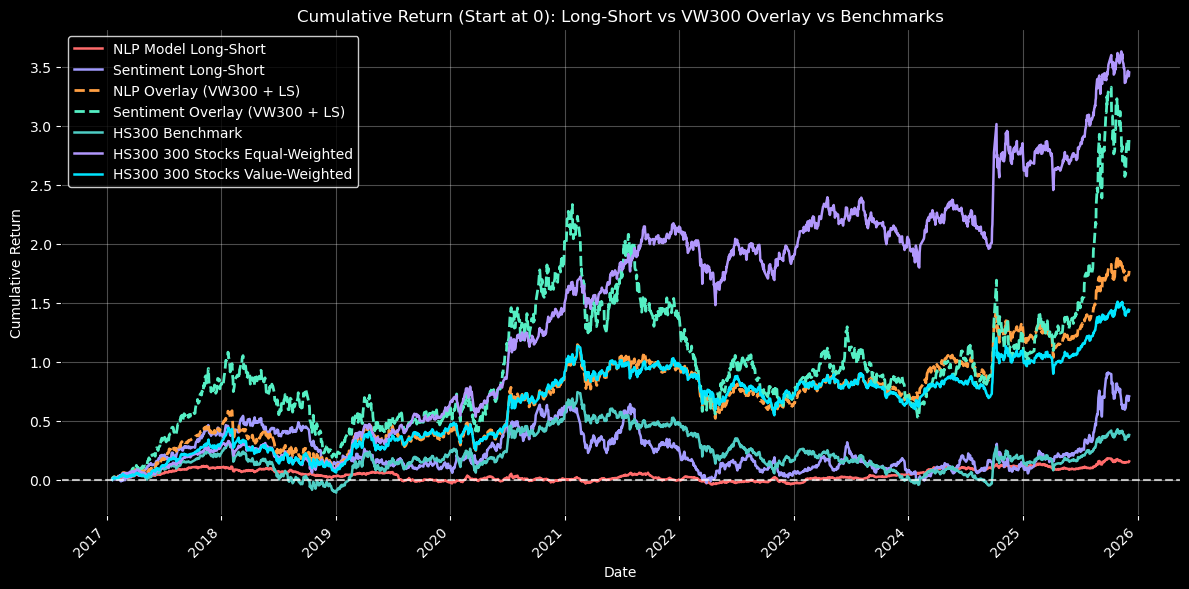

✅ 已保存逐日对比结果: backtest_compare_model_vs_sentiment.csv


In [2]:
# Compare: New NLP Model vs Sentiment Portfolio vs HS300 Benchmark (+ HS300 equal/value weighted)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TRADING_DAYS_PER_YEAR = 252
EXECUTION_LAG_DAYS = 1

def run_daily_long_short_backtest(weight_file, returns_df, lag_days=1):
    w = pd.read_csv(weight_file)
    required_cols = {'date', 'stock', 'weight'}
    if not required_cols.issubset(w.columns):
        raise ValueError(f"{weight_file} 缺少必须列: {required_cols}")

    w['date'] = pd.to_datetime(w['date'].astype(str), format='%Y%m%d', errors='coerce')
    w['stock'] = w['stock'].astype(str).str.zfill(6)
    w['weight'] = pd.to_numeric(w['weight'], errors='coerce')
    w = w.dropna(subset=['date', 'stock', 'weight'])

    wp = w.pivot_table(index='date', columns='stock', values='weight', aggfunc='mean').sort_index().fillna(0.0)
    trading_dates = returns_df['交易日期'].sort_values().unique()
    w_on_trade = wp.reindex(trading_dates).ffill().fillna(0.0)

    if lag_days > 0:
        w_on_trade = w_on_trade.shift(lag_days).fillna(0.0)

    stocks = [c for c in w_on_trade.columns if c in returns_df.columns]
    if len(stocks) == 0:
        raise ValueError(f"{weight_file} 与收益率文件股票列未匹配")

    ret_mat = returns_df.set_index('交易日期')[stocks].reindex(w_on_trade.index).fillna(0.0)
    w_on_trade = w_on_trade[stocks]

    portfolio_ret = (w_on_trade * ret_mat).sum(axis=1)
    benchmark_ret = returns_df.set_index('交易日期').reindex(w_on_trade.index)['沪深300'].fillna(0.0)

    out = pd.DataFrame({
        'date': w_on_trade.index,
        'portfolio_ret': portfolio_ret.values,
        'benchmark_ret': benchmark_ret.values,
    })
    out['portfolio_nav'] = (1.0 + out['portfolio_ret']).cumprod()
    out['benchmark_nav'] = (1.0 + out['benchmark_ret']).cumprod()
    out['daily_net_weight'] = w_on_trade.sum(axis=1).values
    out['daily_gross_weight'] = w_on_trade.abs().sum(axis=1).values
    return out

def perf_stats_from_ret(ret):
    ret = pd.Series(ret).dropna()
    if len(ret) == 0:
        return {'ann_return': np.nan, 'ann_vol': np.nan, 'sharpe': np.nan, 'max_drawdown': np.nan, 'win_rate': np.nan, 'total_return': np.nan}
    nav = (1.0 + ret).cumprod()
    ann_return = nav.iloc[-1] ** (TRADING_DAYS_PER_YEAR / len(ret)) - 1.0
    ann_vol = ret.std(ddof=0) * np.sqrt(TRADING_DAYS_PER_YEAR)
    sharpe = ann_return / ann_vol if ann_vol > 1e-12 else np.nan
    max_dd = (nav / nav.cummax() - 1.0).min()
    win_rate = (ret > 0).mean()
    total_return = nav.iloc[-1] - 1.0
    return {
        'ann_return': float(ann_return),
        'ann_vol': float(ann_vol),
        'sharpe': float(sharpe) if pd.notna(sharpe) else np.nan,
        'max_drawdown': float(max_dd),
        'win_rate': float(win_rate),
        'total_return': float(total_return),
    }

def parse_trade_date_col(date_series):
    raw = date_series.astype(str).str.strip()
    dt = pd.to_datetime(raw, format='%Y%m%d', errors='coerce')
    bad = dt.isna()
    if bad.any():
        dt2 = pd.to_datetime(raw[bad], format='%Y-%m-%d', errors='coerce')
        dt.loc[bad] = dt2
    bad = dt.isna()
    if bad.any():
        dt2 = pd.to_datetime(raw[bad], format='%Y/%m/%d', errors='coerce')
        dt.loc[bad] = dt2
    return dt

# Load returns once using same scale as cell 26
returns_df = pd.read_csv('all_stock_returns.csv')
returns_df['交易日期'] = pd.to_datetime(returns_df['交易日期'], errors='coerce')
returns_df = returns_df.dropna(subset=['交易日期']).sort_values('交易日期').reset_index(drop=True)
for c in returns_df.columns:
    if c != '交易日期':
        returns_df[c] = pd.to_numeric(returns_df[c], errors='coerce') / 100.0

if '沪深300' not in returns_df.columns:
    raise ValueError('all_stock_returns.csv 缺少 沪深300 列，无法做 benchmark 对比')

model_res = run_daily_long_short_backtest('daily_weights_finbert_base.csv', returns_df, lag_days=EXECUTION_LAG_DAYS)
sent_res = run_daily_long_short_backtest('daily_weights_sentiment.csv', returns_df, lag_days=EXECUTION_LAG_DAYS)

model_start_date = model_res.loc[model_res['daily_gross_weight'] > 1e-12, 'date'].min()
if pd.isna(model_start_date):
    raise ValueError('NLP model 无有效持仓日，无法确定回测起点')
print(f'ℹ️ 回测起点已调整为 NLP 模型首个持仓日: {model_start_date.date()}')
print('ℹ️ 当前 Sentiment Portfolio / NLP Model Portfolio 为 pure long-short 回报（未自动叠加 beta=1 基准）')
print('ℹ️ Overlay 口径已改为：HS300 300 Stocks Value-Weighted + long-short')

cmp = pd.merge(
    model_res[['date', 'portfolio_ret', 'benchmark_ret']],
    sent_res[['date', 'portfolio_ret']],
    on='date', how='inner', suffixes=('_model', '_sentiment')
)
cmp = cmp[cmp['date'] >= model_start_date].copy()

# Build HS300 300-stock equal-weight and value-weighted returns on same comparison period
HS300_MAPPING_FILE = os.path.join('Eastmoney_report_pdf_download', 'HS300.csv')
if os.path.exists(HS300_MAPPING_FILE):
    hs300_map = pd.read_csv(HS300_MAPPING_FILE, dtype=str)
    hs300_stocks = hs300_map['股票代码'].astype(str).str.zfill(6).tolist()
else:
    hs300_stocks = []

hs300_available = [c for c in hs300_stocks if c in returns_df.columns]
if len(hs300_available) == 0:
    hs300_available = [
        c for c in returns_df.columns
        if c not in ['交易日期', '沪深300'] and str(c).isdigit() and len(str(c)) == 6
    ]

cmp_dates = pd.to_datetime(cmp['date'])
hs300_panel = returns_df.set_index('交易日期')[hs300_available].reindex(cmp_dates).fillna(0.0)
eq300_ret = hs300_panel.mean(axis=1)

mcap_panels = []
for stock in hs300_available:
    stock_file = os.path.join('trading_data', f'{stock}.csv')
    if not os.path.exists(stock_file):
        continue
    try:
        cap_df = pd.read_csv(stock_file, usecols=['交易日期', '流通市值(万元)', '总市值(万元)'])
    except Exception:
        continue

    cap_df['交易日期'] = parse_trade_date_col(cap_df['交易日期'])
    if '流通市值(万元)' in cap_df.columns:
        cap_df['流通市值(万元)'] = pd.to_numeric(cap_df['流通市值(万元)'], errors='coerce')
    if '总市值(万元)' in cap_df.columns:
        cap_df['总市值(万元)'] = pd.to_numeric(cap_df['总市值(万元)'], errors='coerce')

    if '流通市值(万元)' in cap_df.columns and cap_df['流通市值(万元)'].notna().any():
        cap_col = '流通市值(万元)'
    elif '总市值(万元)' in cap_df.columns and cap_df['总市值(万元)'].notna().any():
        cap_col = '总市值(万元)'
    else:
        continue

    cap_df = cap_df.dropna(subset=['交易日期', cap_col])
    if cap_df.empty:
        continue

    cap_ser = cap_df.sort_values('交易日期').drop_duplicates('交易日期', keep='last').set_index('交易日期')[cap_col]
    cap_ser.name = stock
    mcap_panels.append(cap_ser)

if len(mcap_panels) > 0:
    mcap_panel = pd.concat(mcap_panels, axis=1).reindex(cmp_dates).astype(float)
    mcap_panel = mcap_panel.where(mcap_panel > 0)
    mcap_panel_lag = mcap_panel.shift(1)
    mcap_sum = mcap_panel_lag.sum(axis=1, min_count=1)
    vw_weights = mcap_panel_lag.div(mcap_sum, axis=0)
    aligned_ret_panel = hs300_panel.reindex(columns=vw_weights.columns).fillna(0.0)
    vw300_ret = (aligned_ret_panel * vw_weights.fillna(0.0)).sum(axis=1)
    print(f'ℹ️ Cell 27 value-weighted constituents used: {len(vw_weights.columns)} (t-1 market-cap weights)')
else:
    print('⚠️ Cell 27 未读取到成分股市值文件，value-weighted return 回退为指数口径')
    vw300_ret = cmp.set_index('date')['benchmark_ret']

cmp['ret_eq300'] = eq300_ret.values
cmp['ret_vw300'] = vw300_ret.values

# Overlay portfolios: HS300 300 Stocks Value-Weighted(风险敞口=1) + long-short alpha leg
cmp['ret_model_overlay'] = cmp['ret_vw300'] + cmp['portfolio_ret_model']
cmp['ret_sent_overlay'] = cmp['ret_vw300'] + cmp['portfolio_ret_sentiment']

cmp['cumret_model'] = (1.0 + cmp['portfolio_ret_model']).cumprod() - 1.0
cmp['cumret_sentiment'] = (1.0 + cmp['portfolio_ret_sentiment']).cumprod() - 1.0
cmp['cumret_benchmark'] = (1.0 + cmp['benchmark_ret']).cumprod() - 1.0
cmp['cumret_eq300'] = (1.0 + cmp['ret_eq300']).cumprod() - 1.0
cmp['cumret_vw300'] = (1.0 + cmp['ret_vw300']).cumprod() - 1.0
cmp['cumret_model_overlay'] = (1.0 + cmp['ret_model_overlay']).cumprod() - 1.0
cmp['cumret_sent_overlay'] = (1.0 + cmp['ret_sent_overlay']).cumprod() - 1.0

# metrics table
rows = []
rows.append({'strategy': 'NLP Model Portfolio (Long-Short)', **perf_stats_from_ret(cmp['portfolio_ret_model'])})
rows.append({'strategy': 'Sentiment Portfolio (Long-Short)', **perf_stats_from_ret(cmp['portfolio_ret_sentiment'])})
rows.append({'strategy': 'NLP Overlay = VW300 + NLP Long-Short', **perf_stats_from_ret(cmp['ret_model_overlay'])})
rows.append({'strategy': 'Sentiment Overlay = VW300 + Sentiment Long-Short', **perf_stats_from_ret(cmp['ret_sent_overlay'])})
rows.append({'strategy': 'HS300 Benchmark', **perf_stats_from_ret(cmp['benchmark_ret'])})
rows.append({'strategy': 'HS300 300 Stocks Equal-Weighted', **perf_stats_from_ret(cmp['ret_eq300'])})
rows.append({'strategy': 'HS300 300 Stocks Value-Weighted', **perf_stats_from_ret(cmp['ret_vw300'])})
compare_metrics = pd.DataFrame(rows)

print('=== Performance Comparison (same period, same lag) ===')
display(compare_metrics)

# Cumulative return comparison plot (start at 0)
fig_cmp, ax_cmp = plt.subplots(figsize=(12, 6))
fig_cmp.patch.set_facecolor('black')
ax_cmp.plot(cmp['date'], cmp['cumret_model'], color='#FF6B6B', linewidth=1.8, label='NLP Model Long-Short')
ax_cmp.plot(cmp['date'], cmp['cumret_sentiment'], color='#A29BFE', linewidth=1.8, label='Sentiment Long-Short')
ax_cmp.plot(cmp['date'], cmp['cumret_model_overlay'], color='#FF9F43', linewidth=2.0, linestyle='--', label='NLP Overlay (VW300 + LS)')
ax_cmp.plot(cmp['date'], cmp['cumret_sent_overlay'], color='#55EFC4', linewidth=2.0, linestyle='--', label='Sentiment Overlay (VW300 + LS)')
ax_cmp.plot(cmp['date'], cmp['cumret_benchmark'], color='#4ECDC4', linewidth=1.8, label='HS300 Benchmark')
ax_cmp.plot(cmp['date'], cmp['cumret_eq300'], color='#B197FC', linewidth=1.8, label='HS300 300 Stocks Equal-Weighted')
ax_cmp.plot(cmp['date'], cmp['cumret_vw300'], color='#00E5FF', linewidth=1.8, label='HS300 300 Stocks Value-Weighted')
ax_cmp.axhline(0, color='white', linestyle='--', alpha=0.7)
style_dark_axis(ax_cmp, 'Cumulative Return (Start at 0): Long-Short vs VW300 Overlay vs Benchmarks', 'Cumulative Return')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# export merged comparison table
cmp.to_csv('backtest_compare_model_vs_sentiment.csv', index=False, encoding='utf-8-sig')
print('✅ 已保存逐日对比结果: backtest_compare_model_vs_sentiment.csv')

Building base FinBERT weights...


Scoring base FinBERT: 100%|██████████| 1504/1504 [01:54<00:00, 13.16it/s]
C:\Users\Administrator\AppData\Local\Temp\ipykernel_344088\166495725.py:238: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  panel = panel.groupby('stock', group_keys=False).apply(add_rolling_score).reset_index(drop=True)


✅ Saved daily_weights_finbert_base.csv
ℹ️ Long-short quantile: 20% / 20%, skipped dates (insufficient data): 14
✅ 策略收益使用 DuckDB 计算: trading_data.duckdb
ℹ️ 从 DuckDB 提取股票数: 291，交易日数: 2168
ℹ️ 回测起点已调整为 NLP 模型首个持仓日: 2017-01-19
=== 4-way Performance Comparison (same period, same lag) ===


,strategy,ann_return,ann_vol,sharpe,max_drawdown,win_rate,total_return
0,Sentiment Portfolio,0.048138,0.205479,0.234273,-0.418596,0.508813,0.495175
1,FinBERT Base Portfolio (Top/Bottom 20%),0.014753,0.057279,0.257569,-0.137456,0.513915,0.133490
2,HS300 Benchmark,0.037736,0.186849,0.201959,-0.456026,0.509276,0.372877


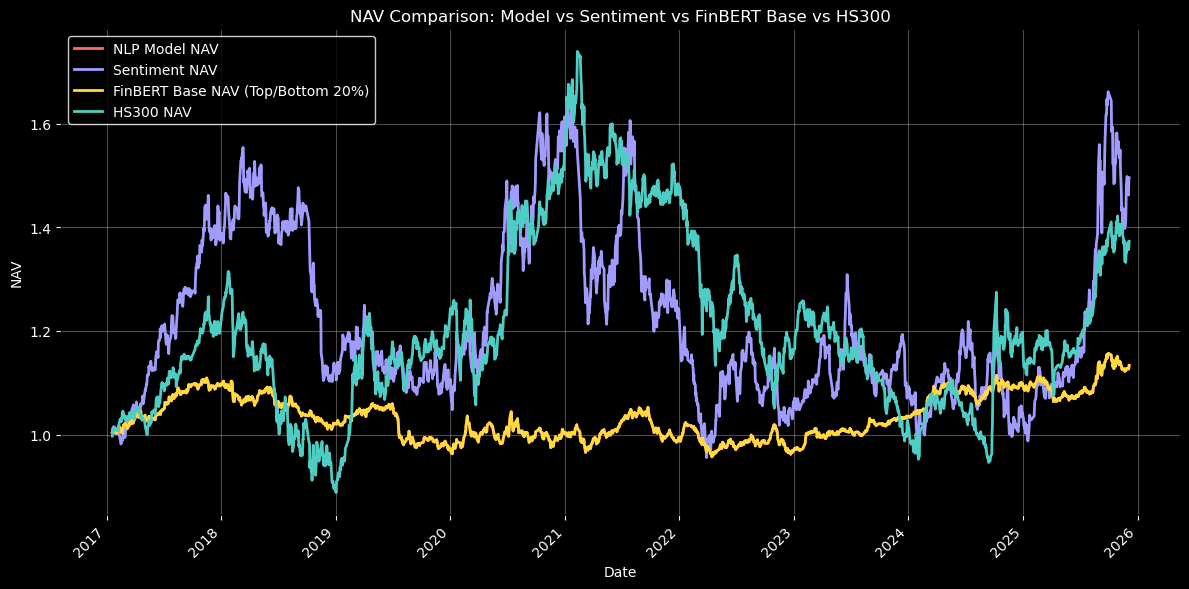

✅ Saved: backtest_compare_4way.csv
✅ Saved: backtest_compare_4way_metrics.csv


In [7]:
# Build un-fine-tuned FinBERT baseline portfolio and compare (Top/Bottom 20%, DuckDB returns)
import os
import numpy as np
import pandas as pd
import duckdb
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification

BASE_MODEL_NAME = 'ProsusAI/finbert'
BASE_WEIGHT_FILE = 'daily_weights_finbert_base.csv'
DATA_FILE = 'daily_text_3m_return_dataset.csv'
MAPPING_FILE = os.path.join('Eastmoney_report_pdf_download', 'HS300.csv')
DB_PATH = 'trading_data.duckdb'
ROLLING_HORIZON_DAYS = 90
LONG_SHORT_Q = 0.20
MIN_STOCKS_PER_SIDE = 5
BATCH_SIZE = 16
MAX_LENGTH = 512
TRADING_DAYS_PER_YEAR = 252
EXECUTION_LAG_DAYS = 1
FORCE_REBUILD_BASE_WEIGHTS = True
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def normalize_stock_code(code):
    if pd.isna(code):
        return np.nan
    s = str(code).strip().upper()
    if s == '' or s == 'NAN':
        return np.nan
    if '.' in s:
        s = s.split('.', 1)[0]
    digits = ''.join(ch for ch in s if ch.isdigit())
    return digits.zfill(6) if digits else np.nan

if 'run_daily_long_short_backtest' not in globals():
    def run_daily_long_short_backtest(weight_file, returns_df, lag_days=1):
        w = pd.read_csv(weight_file)
        required_cols = {'date', 'stock', 'weight'}
        if not required_cols.issubset(w.columns):
            raise ValueError(f"{weight_file} 缺少必须列: {required_cols}")

        w['date'] = pd.to_datetime(w['date'].astype(str), format='%Y%m%d', errors='coerce')
        w['stock'] = w['stock'].astype(str).str.zfill(6)
        w['weight'] = pd.to_numeric(w['weight'], errors='coerce')
        w = w.dropna(subset=['date', 'stock', 'weight'])

        wp = w.pivot_table(index='date', columns='stock', values='weight', aggfunc='mean').sort_index().fillna(0.0)
        trading_dates = returns_df['交易日期'].sort_values().unique()
        w_on_trade = wp.reindex(trading_dates).ffill().fillna(0.0)

        if lag_days > 0:
            w_on_trade = w_on_trade.shift(lag_days).fillna(0.0)

        stocks = [c for c in w_on_trade.columns if c in returns_df.columns]
        if len(stocks) == 0:
            raise ValueError(f"{weight_file} 与收益率文件股票列未匹配")

        ret_mat = returns_df.set_index('交易日期')[stocks].reindex(w_on_trade.index).fillna(0.0)
        w_on_trade = w_on_trade[stocks]

        portfolio_ret = (w_on_trade * ret_mat).sum(axis=1)
        benchmark_ret = returns_df.set_index('交易日期').reindex(w_on_trade.index)['沪深300'].fillna(0.0)

        out = pd.DataFrame({
            'date': w_on_trade.index,
            'portfolio_ret': portfolio_ret.values,
            'benchmark_ret': benchmark_ret.values,
        })
        out['portfolio_nav'] = (1.0 + out['portfolio_ret']).cumprod()
        out['benchmark_nav'] = (1.0 + out['benchmark_ret']).cumprod()
        out['daily_net_weight'] = w_on_trade.sum(axis=1).values
        out['daily_gross_weight'] = w_on_trade.abs().sum(axis=1).values
        return out

if 'perf_stats_from_ret' not in globals():
    def perf_stats_from_ret(ret):
        ret = pd.Series(ret).dropna()
        if len(ret) == 0:
            return {'ann_return': np.nan, 'ann_vol': np.nan, 'sharpe': np.nan, 'max_drawdown': np.nan, 'win_rate': np.nan, 'total_return': np.nan}
        nav = (1.0 + ret).cumprod()
        ann_return = nav.iloc[-1] ** (TRADING_DAYS_PER_YEAR / len(ret)) - 1.0
        ann_vol = ret.std(ddof=0) * np.sqrt(TRADING_DAYS_PER_YEAR)
        sharpe = ann_return / ann_vol if ann_vol > 1e-12 else np.nan
        max_dd = (nav / nav.cummax() - 1.0).min()
        win_rate = (ret > 0).mean()
        total_return = nav.iloc[-1] - 1.0
        return {
            'ann_return': float(ann_return),
            'ann_vol': float(ann_vol),
            'sharpe': float(sharpe) if pd.notna(sharpe) else np.nan,
            'max_drawdown': float(max_dd),
            'win_rate': float(win_rate),
            'total_return': float(total_return),
        }

if 'style_dark_axis' not in globals():
    import matplotlib.pyplot as plt
    def style_dark_axis(ax, title, ylabel):
        ax.set_facecolor('black')
        ax.set_title(title, color='white')
        ax.set_xlabel('Date', color='white')
        ax.set_ylabel(ylabel, color='white')
        ax.grid(True, alpha=0.3, color='white')
        ax.tick_params(axis='x', colors='white')
        ax.tick_params(axis='y', colors='white')
        legend = ax.legend(facecolor='black', edgecolor='white')
        for text in legend.get_texts():
            text.set_color('white')

def load_returns_from_duckdb(db_path, weight_files, start_date='2017-01-01'):
    stock_set = set()
    for wf in weight_files:
        if not os.path.exists(wf):
            continue
        tmp = pd.read_csv(wf, usecols=['stock'])
        stock_set.update(tmp['stock'].astype(str).str.zfill(6).tolist())

    if len(stock_set) == 0:
        raise ValueError('未在权重文件中读取到任何股票代码，无法从 DuckDB 提取收益。')

    with duckdb.connect(db_path, read_only=True) as con:
        raw = con.execute(f"""
            SELECT trade_date, stock_code, change_pct, close, prev_close
            FROM trading_data_clean
            WHERE trade_date IS NOT NULL
              AND stock_code IS NOT NULL
              AND trade_date >= '{start_date}'
        """).fetchdf()

    raw['交易日期'] = pd.to_datetime(raw['trade_date'], errors='coerce')
    raw['stock_norm'] = raw['stock_code'].apply(normalize_stock_code)
    raw['change_pct'] = pd.to_numeric(raw['change_pct'], errors='coerce')
    raw['close'] = pd.to_numeric(raw['close'], errors='coerce')
    raw['prev_close'] = pd.to_numeric(raw['prev_close'], errors='coerce')
    raw = raw.dropna(subset=['交易日期', 'stock_norm'])

    idx_df = raw[raw['stock_norm'] == '000300'].copy()
    idx_df['沪深300'] = np.where(
        idx_df['change_pct'].notna(),
        idx_df['change_pct'] / 100.0,
        np.where(idx_df['prev_close'] > 0, idx_df['close'] / idx_df['prev_close'] - 1.0, np.nan)
    )
    idx_ser = idx_df.groupby('交易日期', as_index=True)['沪深300'].mean()

    stk_df = raw[raw['stock_norm'].isin(stock_set)].copy()
    stk_df['ret'] = stk_df['change_pct'] / 100.0
    stk_df = stk_df.dropna(subset=['ret'])
    stk_daily = stk_df.groupby(['交易日期', 'stock_norm'], as_index=False)['ret'].mean()
    stk_wide = stk_daily.pivot(index='交易日期', columns='stock_norm', values='ret').sort_index()

    returns_df = stk_wide.copy()
    returns_df['沪深300'] = idx_ser.reindex(returns_df.index)
    returns_df = returns_df.reset_index()

    if returns_df['沪深300'].isna().all():
        raise ValueError('DuckDB 中未提取到有效的 000300 指数收益。')

    print(f'✅ 策略收益使用 DuckDB 计算: {db_path}')
    print(f'ℹ️ 从 DuckDB 提取股票数: {len(stk_wide.columns)}，交易日数: {len(returns_df)}')
    return returns_df

if FORCE_REBUILD_BASE_WEIGHTS or (not os.path.exists(BASE_WEIGHT_FILE)):
    print('Building base FinBERT weights...')
    mapping = pd.read_csv(MAPPING_FILE, dtype=str)
    mapping['股票代码'] = mapping['股票代码'].str.zfill(6)
    mapping = mapping.drop_duplicates(subset=['股票代码'], keep='first')
    stock_universe = mapping[['股票代码', '股票简称']].copy()
    stock_universe.columns = ['stock', 'name']

    df = pd.read_csv(DATA_FILE)
    need_cols = {'text', 'report_date', 'stock_code'}
    if not need_cols.issubset(df.columns):
        raise ValueError(f"{DATA_FILE} missing columns: {need_cols}")

    df = df.dropna(subset=['text', 'report_date', 'stock_code']).copy()
    df['text'] = df['text'].astype(str)
    df['date'] = pd.to_datetime(df['report_date'], errors='coerce')
    df['stock'] = df['stock_code'].astype(str).str.zfill(6)
    df = df.dropna(subset=['date'])
    df = df[df['stock'].isin(set(stock_universe['stock']))].reset_index(drop=True)

    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL_NAME).to(DEVICE)
    model.eval()

    id2label = {int(k): v.lower() for k, v in model.config.id2label.items()}
    pos_ids = [k for k, v in id2label.items() if 'positive' in v]
    neg_ids = [k for k, v in id2label.items() if 'negative' in v]
    if len(pos_ids) == 0 or len(neg_ids) == 0:
        raise ValueError(f'Cannot find positive/negative labels in model.config.id2label: {model.config.id2label}')
    pos_id, neg_id = pos_ids[0], neg_ids[0]

    class ReportDataset(Dataset):
        def __init__(self, frame):
            self.frame = frame.reset_index(drop=True)
        def __len__(self):
            return len(self.frame)
        def __getitem__(self, idx):
            row = self.frame.iloc[idx]
            return {'text': row['text'], 'date': row['date'], 'stock': row['stock']}

    def collate_fn(batch):
        texts = [x['text'] for x in batch]
        enc = tokenizer(texts, padding='max_length', truncation=True, max_length=MAX_LENGTH, return_tensors='pt')
        meta = [{'date': x['date'], 'stock': x['stock']} for x in batch]
        return {'input_ids': enc['input_ids'], 'attention_mask': enc['attention_mask'], 'meta': meta}

    dataset = ReportDataset(df)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

    pred_rows = []
    with torch.no_grad():
        for batch in tqdm(loader, total=len(loader), desc='Scoring base FinBERT'):
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
            for meta, p in zip(batch['meta'], probs):
                score_raw = float(p[pos_id] - p[neg_id])
                pred_rows.append({'date': pd.to_datetime(meta['date']).normalize(), 'stock': meta['stock'], 'score_raw': score_raw})

    pred_df = pd.DataFrame(pred_rows)
    daily_raw = pred_df.groupby(['date', 'stock'], as_index=False)['score_raw'].mean()

    all_dates = pd.date_range(daily_raw['date'].min(), daily_raw['date'].max(), freq='D')
    full_index = pd.MultiIndex.from_product([all_dates, stock_universe['stock'].tolist()], names=['date', 'stock'])
    panel = pd.DataFrame(index=full_index).reset_index()
    panel = panel.merge(daily_raw, on=['date', 'stock'], how='left')
    panel = panel.sort_values(['stock', 'date']).reset_index(drop=True)

    def add_rolling_score(group):
        group = group.sort_values('date').copy()
        group['base_score'] = group.set_index('date')['score_raw'].rolling(f'{ROLLING_HORIZON_DAYS}D', min_periods=1).mean().values
        return group

    panel = panel.groupby('stock', group_keys=False).apply(add_rolling_score).reset_index(drop=True)
    panel['base_score'] = panel['base_score'].fillna(0.0)
    panel = panel.merge(stock_universe, on='stock', how='left')

    results = []
    skipped_dates = 0
    for d in all_dates:
        d_str = d.strftime('%Y%m%d')
        day_df = panel[panel['date'] == d][['stock', 'name', 'base_score']].copy()
        day_df = day_df.rename(columns={'base_score': 'score'})
        nonzero_df = day_df[day_df['score'] != 0].copy()

        n_side = int(np.floor(len(nonzero_df) * LONG_SHORT_Q))
        if n_side < MIN_STOCKS_PER_SIDE:
            skipped_dates += 1
            continue

        sorted_df = nonzero_df.sort_values(by='score', ascending=False)
        longs = sorted_df.head(n_side)
        shorts = sorted_df.tail(n_side)

        if len(longs) == 0 or len(shorts) == 0:
            skipped_dates += 1
            continue

        w_long = 0.5 / len(longs)
        w_short = -0.5 / len(shorts)

        for _, row in longs.iterrows():
            results.append([d_str, row['stock'], row['name'], row['score'], w_long])
        for _, row in shorts.iterrows():
            results.append([d_str, row['stock'], row['name'], row['score'], w_short])

    base_weights_df = pd.DataFrame(results, columns=['date', 'stock', 'name', 'score', 'weight'])
    base_weights_df.to_csv(BASE_WEIGHT_FILE, index=False, encoding='utf-8-sig')
    print(f'✅ Saved {BASE_WEIGHT_FILE}')
    print(f'ℹ️ Long-short quantile: {LONG_SHORT_Q:.0%} / {LONG_SHORT_Q:.0%}, skipped dates (insufficient data): {skipped_dates}')
else:
    print(f'Using existing {BASE_WEIGHT_FILE}')
    print(f'ℹ️ 请确认 {BASE_WEIGHT_FILE} 已按前后 20% long-short 口径生成。')

# Compare 4 portfolios on same backtest engine (returns from DuckDB)
returns_df = load_returns_from_duckdb(
    db_path=DB_PATH,
    weight_files=['daily_weights_finbert_base.csv', 'daily_weights_sentiment.csv', BASE_WEIGHT_FILE],
    start_date='2017-01-01'
  )

if '沪深300' not in returns_df.columns:
    raise ValueError('DuckDB 回测数据缺少 沪深300 列，无法做 benchmark 对比')

model_res = run_daily_long_short_backtest('daily_weights_finbert_base.csv', returns_df, lag_days=EXECUTION_LAG_DAYS)
sent_res = run_daily_long_short_backtest('daily_weights_sentiment.csv', returns_df, lag_days=EXECUTION_LAG_DAYS)
base_res = run_daily_long_short_backtest(BASE_WEIGHT_FILE, returns_df, lag_days=EXECUTION_LAG_DAYS)

model_start_date = model_res.loc[model_res['daily_gross_weight'] > 1e-12, 'date'].min()
if pd.isna(model_start_date):
    raise ValueError('NLP model 无有效持仓日，无法确定回测起点')
print(f'ℹ️ 回测起点已调整为 NLP 模型首个持仓日: {model_start_date.date()}')

cmp4 = model_res[['date', 'portfolio_ret', 'benchmark_ret']].rename(columns={'portfolio_ret':'ret_model'})
cmp4 = cmp4.merge(sent_res[['date','portfolio_ret']].rename(columns={'portfolio_ret':'ret_sent'}), on='date', how='inner')
cmp4 = cmp4.merge(base_res[['date','portfolio_ret']].rename(columns={'portfolio_ret':'ret_finbert_base'}), on='date', how='inner')
cmp4 = cmp4[cmp4['date'] >= model_start_date].copy()

cmp4['nav_model'] = (1.0 + cmp4['ret_model']).cumprod()
cmp4['nav_sent'] = (1.0 + cmp4['ret_sent']).cumprod()
cmp4['nav_finbert_base'] = (1.0 + cmp4['ret_finbert_base']).cumprod()
cmp4['benchmark_nav'] = (1.0 + cmp4['benchmark_ret']).cumprod()

rows = [
    {'strategy':'Sentiment Portfolio', **perf_stats_from_ret(cmp4['ret_sent'])},
    {'strategy':'FinBERT Base Portfolio (Top/Bottom 20%)', **perf_stats_from_ret(cmp4['ret_finbert_base'])},
    {'strategy':'HS300 Benchmark', **perf_stats_from_ret(cmp4['benchmark_ret'])},
]
compare4_metrics = pd.DataFrame(rows)
print('=== 4-way Performance Comparison (same period, same lag) ===')
display(compare4_metrics)

fig4, ax4 = plt.subplots(figsize=(12, 6))
fig4.patch.set_facecolor('black')
ax4.plot(cmp4['date'], cmp4['nav_model'], color='#FF6B6B', linewidth=2.0, label='NLP Model NAV')
ax4.plot(cmp4['date'], cmp4['nav_sent'], color='#A29BFE', linewidth=2.0, label='Sentiment NAV')
ax4.plot(cmp4['date'], cmp4['nav_finbert_base'], color='#FFD93D', linewidth=2.0, label='FinBERT Base NAV (Top/Bottom 20%)')
ax4.plot(cmp4['date'], cmp4['benchmark_nav'], color='#4ECDC4', linewidth=2.0, label='HS300 NAV')
style_dark_axis(ax4, 'NAV Comparison: Model vs Sentiment vs FinBERT Base vs HS300', 'NAV')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

cmp4.to_csv('backtest_compare_4way.csv', index=False, encoding='utf-8-sig')
compare4_metrics.to_csv('backtest_compare_4way_metrics.csv', index=False, encoding='utf-8-sig')
print('✅ Saved: backtest_compare_4way.csv')
print('✅ Saved: backtest_compare_4way_metrics.csv')

In [41]:
diag = pd.DataFrame({
    'date': plot_dates.values,
    'model_cum': model_cum_ret.values,
    'eq300_cum': eq300_cum_ret,
    'vw300_cum': vw300_cum_ret,
    'vw300_ret': vw300_ret.values,
    'idx_ret': plot_result['benchmark_ret'].values,
})
print('=== Cumulative Return End ===')
print(diag[['model_cum','eq300_cum','vw300_cum']].iloc[-1])
print('\n=== Daily Return Scale ===')
print('vw abs mean:', diag['vw300_ret'].abs().mean())
print('idx abs mean:', diag['idx_ret'].abs().mean())
print('corr(vw, idx):', diag['vw300_ret'].corr(diag['idx_ret']))

print('\n=== Weight/Cap Diagnostics ===')
print('mcap_panel non-null ratio:', float(mcap_panel.notna().mean().mean()) if 'mcap_panel' in globals() else 'N/A')
print('mcap_panel_lag non-null ratio:', float(mcap_panel_lag.notna().mean().mean()) if 'mcap_panel_lag' in globals() else 'N/A')
if 'vw_weights' in globals():
    ws = vw_weights.sum(axis=1)
    print('vw_weights sum head:')
    print(ws.head())
    print('vw_weights sum tail:')
    print(ws.tail())

print('\n=== Head/Tail ===')
display(diag[['date','vw300_ret','idx_ret','vw300_cum']].head())
display(diag[['date','vw300_ret','idx_ret','vw300_cum']].tail())

=== Cumulative Return End ===
model_cum    1.469986
eq300_cum    3.389526
vw300_cum    1.446652
Name: 2165, dtype: float64

=== Daily Return Scale ===
vw abs mean: 0.007642714523300706
idx abs mean: 0.008309279778393353
corr(vw, idx): 0.9832550287995885

=== Weight/Cap Diagnostics ===
mcap_panel non-null ratio: 0.9115445513766328
mcap_panel_lag non-null ratio: 0.9110828708595509
vw_weights sum head:
date
2017-01-05    0.0
2017-01-06    1.0
2017-01-09    1.0
2017-01-10    1.0
2017-01-11    1.0
dtype: float64
vw_weights sum tail:
date
2025-12-01    1.0
2025-12-02    1.0
2025-12-03    1.0
2025-12-04    1.0
2025-12-05    1.0
dtype: float64

=== Head/Tail ===


,date,vw300_ret,idx_ret,vw300_cum
0,2017-01-05,0.000000,-0.0002,0.000000
1,2017-01-06,-0.001474,-0.0060,-0.001474
2,2017-01-09,0.004031,0.0048,0.002551
3,2017-01-10,-0.002451,-0.0017,0.000095
4,2017-01-11,-0.005327,-0.0071,-0.005233


,date,vw300_ret,idx_ret,vw300_cum
2161,2025-12-01,0.009125,0.0110,1.449033
2162,2025-12-02,-0.002888,-0.0048,1.441961
2163,2025-12-03,-0.004857,-0.0051,1.430099
2164,2025-12-04,0.001258,0.0034,1.433157
2165,2025-12-05,0.005546,0.0084,1.446652
